# 02 – Análisis Exploratorio de Datos (EDA)

**Entregable 2 – Deep Learning**  
Estado del Arte, EDA Mejorado e Implementación de Modelos Benchmark

---

> **Objetivo del EDA**  
> Este notebook realiza un análisis exploratorio **exhaustivo, profundo y orientado a decisiones de modelado** del dataset AI4MARS.  
> Cada sección termina con una caja de implicaciones estructurada en:  
> `[D] Decisión de diseño | [A] Impacto en arquitectura | [R] Riesgo / data leakage`
>
> **Prerequisito:** ejecutar `01_preprocessing_and_dataset.ipynb` para generar `processed/manifest_clean.csv`.

---

**Índice**
1. [Configuración e importaciones](#setup)
2. [Carga del dataset](#load)
3. [EDA General](#eda-general)
   - 3.1 Distribución de la variable objetivo (píxeles)
   - 3.2 Calidad del dataset – detección de duplicados
   - 3.3 Identificación de sesgos – distribución por misión (domain shift)
   - 3.4 Partición del dataset – split estratificado
4. [EDA Específico para Imágenes](#eda-imagenes)
   - 4.1 Inspección visual por clase
   - 4.2 Dimensionalidad y formato
   - 4.3 Distribución de intensidades de píxeles
   - 4.4 Presencia por imagen y co-ocurrencia de clases
   - 4.5 Tamaño efectivo de objetos por clase
5. [Análisis Avanzados](#avanzados)
   - 5.1 Divergencia Jensen-Shannon entre misiones
   - 5.2 Análisis de píxeles ignore por imagen
   - 5.3 Análisis de bordes vs. interior
   - 5.4 Balance real de batches – WeightedSampler
   - 5.5 Correlación intensidad ↔ clase (KS-test)
6. [Baselines triviales (lower bound mIoU)](#baselines)
7. [Tabla resumen EDA → Decisiones de modelado](#resumen)


## 1. Configuración e importaciones <a id="setup"></a>

Se importan todas las librerías necesarias y se definen las paletas de color utilizadas a lo largo del notebook.  
El uso de colores consistentes para clases y misiones facilita la interpretación visual comparativa.

In [1]:
import os
import warnings
import hashlib
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image
from tqdm import tqdm
from scipy.spatial.distance import jensenshannon
from scipy.stats import ks_2samp
from scipy.ndimage import binary_dilation

warnings.filterwarnings("ignore")

# ── Semilla para reproducibilidad en samplings del EDA ──────────────────────
EDA_SEED = 42

# ── Directorio donde se guardan salidas ─────────────────────────────────────
PROCESSED_DIR = Path("processed")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print("Librerías cargadas")


Librerías cargadas


In [2]:
# ── Paleta de colores por clase (colorblind-friendly) ───────────────────────
CLASS_COLORS = {
    0:   ("#E69F00", "soil"),
    1:   ("#56B4E9", "bedrock"),
    2:   ("#009E73", "sand"),
    3:   ("#D55E00", "big_rock"),
    255: ("#999999", "ignore"),
}
CLASS_NAMES = {c: CLASS_COLORS[c][1] for c in [0, 1, 2, 3]}

# ── Paleta de colores por misión ─────────────────────────────────────────────
MISSION_COLORS = {"MSL": "#0072B2", "MER": "#CC79A7", "M2020": "#F0E442"}

# ── Constantes del problema ──────────────────────────────────────────────────
NUM_CLASSES  = 4      # clases válidas: 0, 1, 2, 3
IGNORE_INDEX = 255    # tratado como "no etiquetado"

print("Constantes y paletas definidas")
print(f"Clases: {list(CLASS_NAMES.values())}")
print(f"Misiones: {list(MISSION_COLORS.keys())}")


Constantes y paletas definidas
Clases: ['soil', 'bedrock', 'sand', 'big_rock']
Misiones: ['MSL', 'MER', 'M2020']


## 2. Carga del dataset limpio <a id="load"></a>

Se carga el manifest generado en el notebook de preprocesamiento.  
Este CSV contiene rutas absolutas a imágenes y máscaras, junto con metadata de misión y cámara.  
Las 963 muestras con máscaras vacías o de solo-ignore ya fueron eliminadas en la etapa anterior.

In [3]:
df_clean = pd.read_csv(PROCESSED_DIR / "manifest_clean.csv")

print(f"Total muestras limpias: {len(df_clean):,}")
print()
print("Distribución por misión:")
print(df_clean["mission"].value_counts().to_string())
print()
print("Columnas disponibles:", df_clean.columns.tolist())
df_clean.head(3)


Total muestras limpias: 22,965

Distribución por misión:
mission
MSL      15901
MER       6593
M2020      471

Columnas disponibles: ['mission', 'camera', 'id', 'image_path', 'mask_path']


,mission,camera,id,image_path,mask_path
0,MSL,ncam,NLB_536962108EDR_F0600000NCAM00654M1,C:\Users\User\Documents\DeepLearning\ai4mars-d...,C:\Users\User\Documents\DeepLearning\ai4mars-d...
1,MSL,ncam,NLB_439406491EDR_F0240192NCAM00354M1,C:\Users\User\Documents\DeepLearning\ai4mars-d...,C:\Users\User\Documents\DeepLearning\ai4mars-d...
2,MSL,ncam,NLB_460082942EDR_F0391918NCAM00391M1,C:\Users\User\Documents\DeepLearning\ai4mars-d...,C:\Users\User\Documents\DeepLearning\ai4mars-d...


## 3. EDA General <a id="eda-general"></a>

> El EDA debe ser **exhaustivo, reproducible y orientado a decisiones de modelado**.  
> Cada análisis responde explícitamente: *¿cómo impacta esto el diseño del modelo o el preprocesamiento?*

---

### 3.1 Distribución de la variable objetivo (píxeles)

Se mide la distribución de píxeles por clase usando un muestreo estratificado sobre el dataset completo.  
Este es el análisis más crítico: determina si existe **desbalance de clases** y qué técnicas son necesarias.

Calculando distribución global de clases (muestra estratificada)...


Contando píxeles: 100%|██████████| 600/600 [00:08<00:00, 70.95it/s]


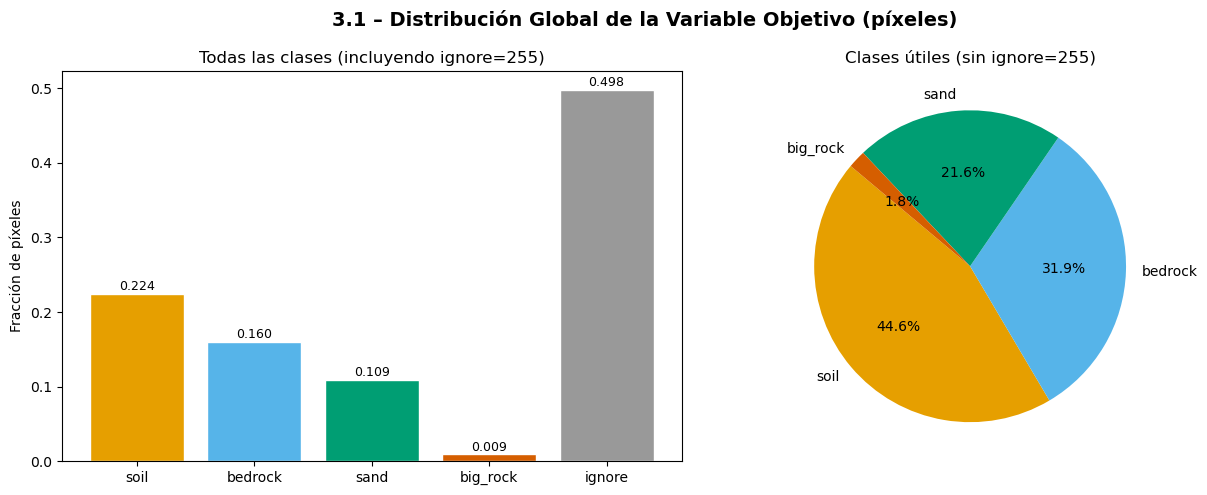


Ratio de desbalance (clase dominante / clase más rara): 24.2x
  ► Clase más frecuente : soil (44.60% de píxeles válidos)
  ► Clase más rara      : big_rock (1.84% de píxeles válidos)


In [4]:
def stratified_sample(df, n_per_mission=100, seed=EDA_SEED):
    """Muestrea n imágenes por misión para mantener representatividad."""    
    return (
        df.groupby("mission", group_keys=False)
          .apply(lambda x: x.sample(min(len(x), n_per_mission), random_state=seed))
          .reset_index(drop=True)
    )

def pixel_class_counts(df, n_per_mission=200, seed=EDA_SEED):
    """Cuenta píxeles totales por clase usando sampling estratificado."""    
    sample = stratified_sample(df, n_per_mission=n_per_mission, seed=seed)
    counts = defaultdict(int)
    for _, row in tqdm(sample.iterrows(), total=len(sample), desc="Contando píxeles"):
        mask = np.array(Image.open(row["mask_path"]))
        vals, cnts = np.unique(mask, return_counts=True)
        for v, c in zip(vals, cnts):
            counts[int(v)] += int(c)
    return dict(counts)

print("Calculando distribución global de clases (muestra estratificada)...")
counts_global = pixel_class_counts(df_clean, n_per_mission=200)
total_px = sum(counts_global.values())

labels_order = [0, 1, 2, 3, 255]
fracs  = [counts_global.get(c, 0) / total_px for c in labels_order]
colors = [CLASS_COLORS[c][0] for c in labels_order]
names  = [CLASS_COLORS[c][1] for c in labels_order]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("3.1 – Distribución Global de la Variable Objetivo (píxeles)", fontsize=14, fontweight="bold")

# Gráfico de barras: todas las clases incluyendo ignore
axes[0].bar(names, fracs, color=colors, edgecolor="white")
axes[0].set_ylabel("Fracción de píxeles")
axes[0].set_title("Todas las clases (incluyendo ignore=255)")
for i, (n, f) in enumerate(zip(names, fracs)):
    axes[0].text(i, f + 0.005, f"{f:.3f}", ha="center", fontsize=9)

# Pie chart: solo clases útiles (sin ignore)
fracs_valid  = [counts_global.get(c, 0) for c in [0, 1, 2, 3]]
names_valid  = [CLASS_COLORS[c][1] for c in [0, 1, 2, 3]]
colors_valid = [CLASS_COLORS[c][0] for c in [0, 1, 2, 3]]
axes[1].pie(fracs_valid, labels=names_valid, colors=colors_valid,
            autopct="%1.1f%%", startangle=140)
axes[1].set_title("Clases útiles (sin ignore=255)")

plt.tight_layout()
plt.savefig(PROCESSED_DIR / "eda_01_class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

# Ratio de desbalance
valid = {c: counts_global.get(c, 0) for c in [0, 1, 2, 3]}
max_c = max(valid, key=valid.get)
min_c = min(valid, key=valid.get)
ratio = valid[max_c] / max(valid[min_c], 1)

print(f"\nRatio de desbalance (clase dominante / clase más rara): {ratio:.1f}x")
print(f"  ► Clase más frecuente : {CLASS_COLORS[max_c][1]} ({valid[max_c]/sum(valid.values()):.2%} de píxeles válidos)")
print(f"  ► Clase más rara      : {CLASS_COLORS[min_c][1]} ({valid[min_c]/sum(valid.values()):.2%} de píxeles válidos)")


** Implicaciones – Distribución de la variable objetivo**

| | |
|---|---|
| **[D] Decisión** | Usar `CrossEntropyLoss(ignore_index=255)` + pesos de clase inversamente proporcionales a frecuencia. `big_rock` necesita ~50× más peso. Considerar Focal Loss (γ=2) como alternativa. |
| **[A] Arquitectura** | La cabeza de clasificación debe tener **4 salidas** (no 5). La métrica principal será **mIoU excluyendo clase 255**. |
| **[R] Riesgo** | `pixel_accuracy` es engañosa (~45% de los píxeles son ignore). **No usar pixel accuracy como métrica principal.** |


---

### 3.2 Calidad del dataset – Detección de duplicados

Se detectan imágenes duplicadas mediante hash perceptual rápido (thumbnail MD5) sobre una muestra del dataset.  
La presencia de duplicados entre train y test constituye **data leakage directo**.

In [5]:
def fast_image_hash(path, size=(32, 32)):
    """Hash rápido basado en thumbnail para detectar duplicados exactos."""    
    img = Image.open(path).convert("L").resize(size)
    return hashlib.md5(np.array(img).tobytes()).hexdigest()

print("Detectando duplicados (muestra de 1000 imágenes)...")
sample_df = df_clean.sample(min(1000, len(df_clean)), random_state=EDA_SEED)
hashes = []
for _, row in tqdm(sample_df.iterrows(), total=len(sample_df), desc="Calculando hashes"):
    try:
        h = fast_image_hash(row["image_path"])
    except Exception:
        h = "error"
    hashes.append(h)

sample_df = sample_df.copy()
sample_df["img_hash"] = hashes
duplicates = sample_df[sample_df.duplicated("img_hash", keep=False)]

print(f"\nImágenes duplicadas encontradas (en muestra de 1000): {len(duplicates)}")
if len(duplicates) > 0:
    print(duplicates[["mission", "id", "img_hash"]].head(10))
else:
    print("No se detectaron duplicados exactos en la muestra.")

print(f"\nDistribución de misiones en la muestra analizada:")
print(sample_df["mission"].value_counts())


Detectando duplicados (muestra de 1000 imágenes)...


Calculando hashes: 100%|██████████| 1000/1000 [00:10<00:00, 99.37it/s]


Imágenes duplicadas encontradas (en muestra de 1000): 0
No se detectaron duplicados exactos en la muestra.

Distribución de misiones en la muestra analizada:
mission
MSL      662
MER      313
M2020     25
Name: count, dtype: int64


** Implicaciones – Calidad del dataset**

| | |
|---|---|
| **[D] Decisión** | Si hay duplicados cross-misión → eliminarlos antes del split. Dentro de misión pueden mantenerse (captura bajo distintas condiciones). |
| **[A] Arquitectura** | No aplica directamente. |
| **[R] Riesgo CRÍTICO** | Duplicados entre train y test = **data leakage directo**. El modelo memoriza imágenes que aparecen en test. Verificar sobre el dataset completo antes del split final. |


---

### 3.3 Identificación de sesgos – Distribución por misión (domain shift)

Se compara la distribución de clases entre misiones. Diferencias sistemáticas indican **domain shift**,  
lo que implica que un modelo entrenado en una misión puede no generalizar a otras.

Calculando distribución por misión...


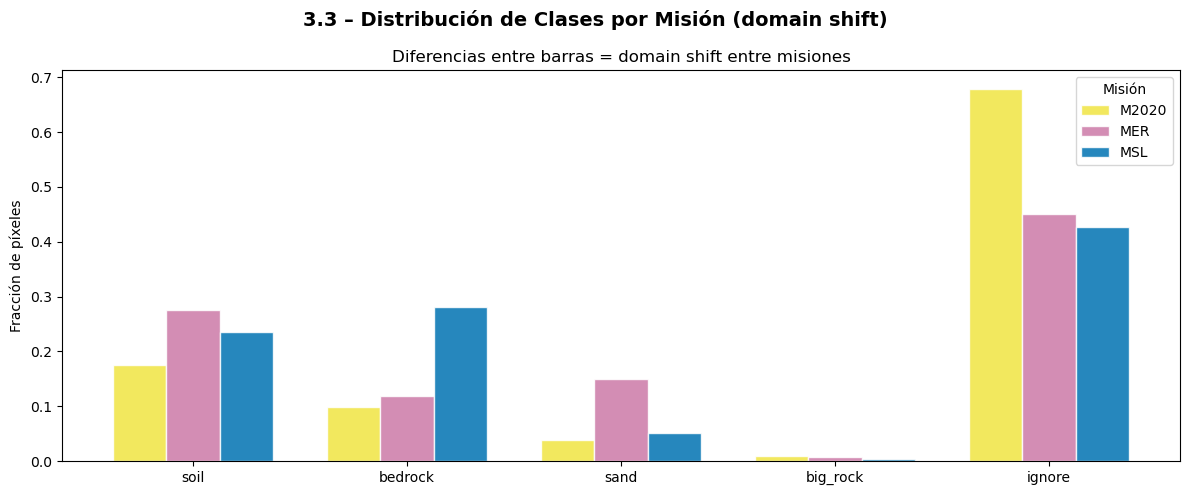


Distribución detallada por misión:
  M2020: {'soil': '0.175', 'bedrock': '0.099', 'sand': '0.038', 'big_rock': '0.009', 'ignore': '0.679'}
  MER: {'soil': '0.275', 'bedrock': '0.118', 'sand': '0.149', 'big_rock': '0.007', 'ignore': '0.451'}
  MSL: {'soil': '0.236', 'bedrock': '0.282', 'sand': '0.051', 'big_rock': '0.004', 'ignore': '0.427'}


In [6]:
def pixel_counts_by_mission(df, sample_per_mission=200, seed=EDA_SEED):
    """Distribución de píxeles por clase para cada misión."""    
    results = {}
    for mission, group in df.groupby("mission"):
        rng = np.random.default_rng(seed)
        idx = rng.choice(len(group), size=min(sample_per_mission, len(group)), replace=False)
        counts = defaultdict(int)
        for i in tqdm(idx, desc=f"  {mission}", leave=False):
            mask = np.array(Image.open(group.iloc[i]["mask_path"]))
            vals, cnts = np.unique(mask, return_counts=True)
            for v, c in zip(vals, cnts):
                counts[int(v)] += int(c)
        total = sum(counts.values())
        results[mission] = {k: v / total for k, v in counts.items()}
    return results

print("Calculando distribución por misión...")
dist_mission = pixel_counts_by_mission(df_clean, sample_per_mission=200)

missions = list(dist_mission.keys())
x = np.arange(len([0, 1, 2, 3, 255]))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 5))
fig.suptitle("3.3 – Distribución de Clases por Misión (domain shift)", fontsize=14, fontweight="bold")

for i, mission in enumerate(missions):
    dist = dist_mission[mission]
    vals = [dist.get(c, 0) for c in [0, 1, 2, 3, 255]]
    ax.bar(x + i * width, vals, width, label=mission,
           color=MISSION_COLORS[mission], edgecolor="white", alpha=0.85)

ax.set_xticks(x + width)
ax.set_xticklabels([CLASS_COLORS[c][1] for c in [0, 1, 2, 3, 255]])
ax.set_ylabel("Fracción de píxeles")
ax.legend(title="Misión")
ax.set_title("Diferencias entre barras = domain shift entre misiones")
plt.tight_layout()
plt.savefig(PROCESSED_DIR / "eda_02_class_by_mission.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nDistribución detallada por misión:")
for mission, dist in dist_mission.items():
    print(f"  {mission}: ", end="")
    print({CLASS_COLORS[k][1]: f"{v:.3f}" for k, v in sorted(dist.items()) if k in [0,1,2,3,255]})


** Implicaciones – Domain shift por misión**

| | |
|---|---|
| **[D] Decisión** | Split **estratificado por misión** para que train/val/test reflejen la distribución real. Evaluar métricas globales **y** por misión por separado. |
| **[A] Arquitectura** | Experimento *cross-mission* obligatorio (train MSL+MER, test M2020). Documentar como prueba de generalización OOD. |
| **[R] Riesgo** | Un split aleatorio puede colocar MSL y M2020 en train/test simultáneamente sin control → el modelo puede aprender features específicas de misión, no de terreno. |


---

### 3.4 Partición del dataset – Split estratificado

Se define la estrategia de split 70/15/15 estratificada por misión para evitar que M2020 (minoría, 2%)  
quede subrepresentada o ausente en val/test.

In [7]:
def split_manifest(
    df: pd.DataFrame,
    train_ratio: float = 0.70,
    val_ratio:   float = 0.15,
    seed: int = EDA_SEED,
):
    """
    Split estratificado por misión (70 / 15 / 15).
    Garantiza que cada misión esté representada en los tres conjuntos.
    El test_ratio implícito es 1 - train_ratio - val_ratio.
    """
    train_frames, val_frames, test_frames = [], [], []

    for mission, group in df.groupby("mission"):
        g = group.sample(frac=1, random_state=seed)
        n = len(g)
        n_tr = int(n * train_ratio)
        n_va = int(n * val_ratio)
        train_frames.append(g.iloc[:n_tr])
        val_frames.append(  g.iloc[n_tr : n_tr + n_va])
        test_frames.append( g.iloc[n_tr + n_va :])

    df_train = pd.concat(train_frames).sample(frac=1, random_state=seed).reset_index(drop=True)
    df_val   = pd.concat(val_frames  ).sample(frac=1, random_state=seed).reset_index(drop=True)
    df_test  = pd.concat(test_frames ).sample(frac=1, random_state=seed).reset_index(drop=True)

    return df_train, df_val, df_test

df_train, df_val, df_test = split_manifest(df_clean)

print("Partición estratificada (70 / 15 / 15):")
for name, df_split in [("TRAIN", df_train), ("VAL", df_val), ("TEST", df_test)]:
    dist = df_split["mission"].value_counts()
    pcts = (dist / len(df_split) * 100).round(1)
    print(f"  {name:5s}: {len(df_split):>5} muestras  |  {dist.to_dict()}  |  {pcts.to_dict()}")

# Guardar los splits para reproducibilidad
df_train.to_csv(PROCESSED_DIR / "split_train.csv", index=False)
df_val.to_csv(  PROCESSED_DIR / "split_val.csv",   index=False)
df_test.to_csv( PROCESSED_DIR / "split_test.csv",  index=False)
print("\nSplits guardados en processed/split_*.csv")


Partición estratificada (70 / 15 / 15):
  TRAIN: 16074 muestras  |  {'MSL': 11130, 'MER': 4615, 'M2020': 329}  |  {'MSL': 69.2, 'MER': 28.7, 'M2020': 2.0}
  VAL  :  3443 muestras  |  {'MSL': 2385, 'MER': 988, 'M2020': 70}  |  {'MSL': 69.3, 'MER': 28.7, 'M2020': 2.0}
  TEST :  3448 muestras  |  {'MSL': 2386, 'MER': 990, 'M2020': 72}  |  {'MSL': 69.2, 'MER': 28.7, 'M2020': 2.1}

Splits guardados en processed/split_*.csv


** Implicaciones – Partición del dataset**

| | |
|---|---|
| **[D] Decisión** | Split **70/15/15 estratificado por misión**. Los CSV de split se guardan y se reutilizan en todos los notebooks de modelos para garantizar **reproducibilidad**. |
| **[A] Arquitectura** | Los splits son fijos y no deben regenerarse con semillas distintas entre experimentos. Usar siempre los CSV de `processed/split_*.csv`. |
| **[R] Riesgo CRÍTICO** | Regenerar el split después de calcular estadísticas de normalización introduce **data leakage**. El orden correcto es: split → calcular stats solo en train → aplicar al resto. |


## 4. EDA Específico para Imágenes <a id="eda-imagenes"></a>

Esta sección implementa los análisis requeridos para datasets de visión computacional:  
inspección visual, dimensionalidad, intensidades, balance de clases y correlación espacial.

---

### 4.1 Inspección visual por clase

Se visualizan muestras representativas de cada clase con el overlay de la máscara correspondiente.  
Permite identificar ruido, artefactos y errores de etiquetado.

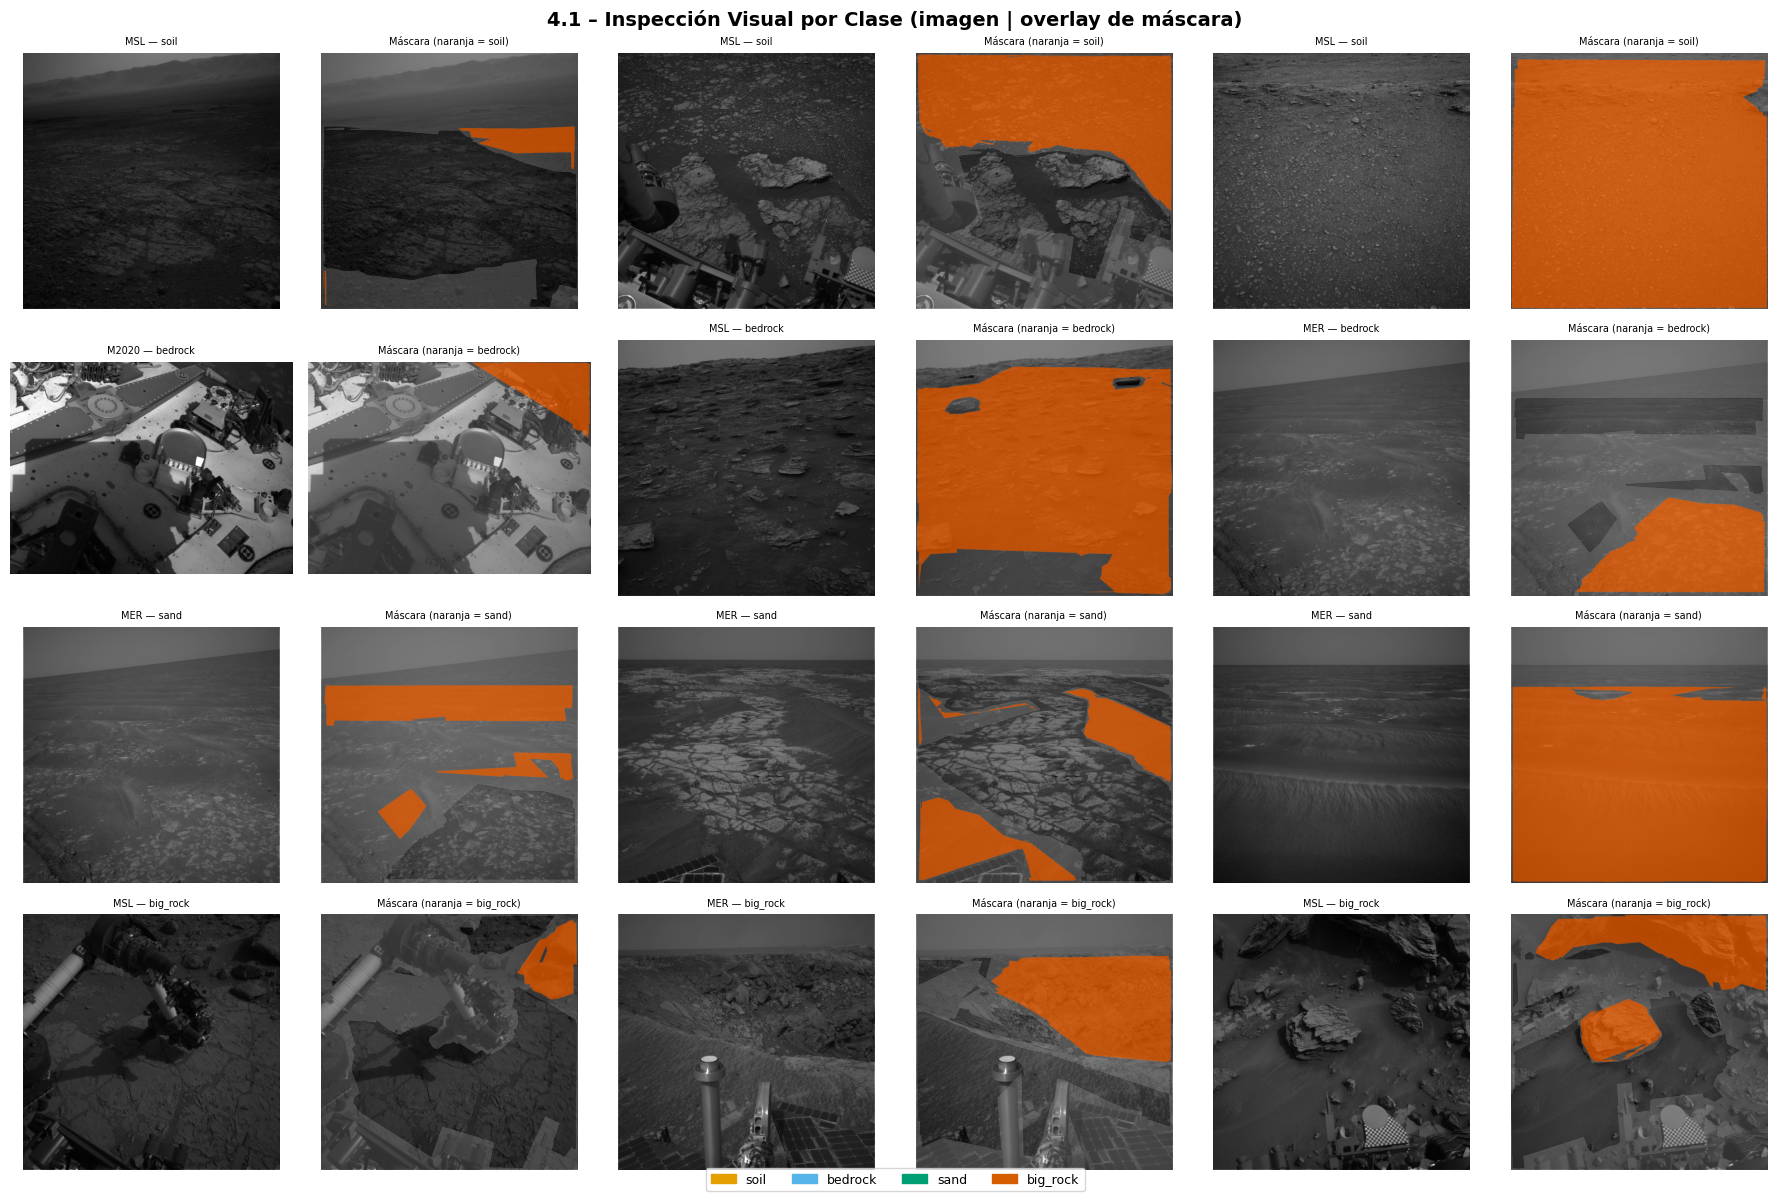

In [8]:
def find_samples_with_class(df, class_id, n=3, min_frac=0.05, seed=EDA_SEED):
    """Busca imágenes donde la clase ocupe al menos min_frac de píxeles válidos."""    
    rng = np.random.default_rng(seed)
    found = []
    indices = rng.permutation(len(df))
    for i in indices:
        if len(found) >= n:
            break
        row = df.iloc[i]
        mask = np.array(Image.open(row["mask_path"]))
        valid = mask[mask != 255]
        if len(valid) == 0:
            continue
        if np.mean(valid == class_id) >= min_frac:
            found.append(i)
    return found

fig, axes = plt.subplots(4, 6, figsize=(18, 12))
fig.suptitle("4.1 – Inspección Visual por Clase (imagen | overlay de máscara)", fontsize=14, fontweight="bold")

for row_idx, cls in enumerate([0, 1, 2, 3]):
    indices = find_samples_with_class(df_clean, cls, n=3, min_frac=0.05)
    for col_idx, sample_i in enumerate(indices[:3]):
        row = df_clean.iloc[sample_i]
        img  = np.array(Image.open(row["image_path"]).convert("L"))
        mask = np.array(Image.open(row["mask_path"]))

        ax_img  = axes[row_idx][col_idx * 2]
        ax_mask = axes[row_idx][col_idx * 2 + 1]

        ax_img.imshow(img, cmap="gray")
        ax_img.set_title(f"{row['mission']} — {CLASS_COLORS[cls][1]}", fontsize=7)
        ax_img.axis("off")

        # Overlay: clase de interés en naranja, ignore en gris semitransparente
        overlay = np.zeros((*mask.shape, 4), dtype=np.uint8)
        overlay[mask == cls]  = [255, 100, 0, 180]
        overlay[mask == 255]  = [150, 150, 150, 80]
        ax_mask.imshow(img, cmap="gray")
        ax_mask.imshow(overlay)
        ax_mask.set_title(f"Máscara (naranja = {CLASS_COLORS[cls][1]})", fontsize=7)
        ax_mask.axis("off")

# Leyenda global
patches = [mpatches.Patch(color=CLASS_COLORS[c][0], label=CLASS_COLORS[c][1]) for c in [0,1,2,3]]
fig.legend(handles=patches, loc="lower center", ncol=4, fontsize=9, bbox_to_anchor=(0.5, -0.01))
plt.tight_layout()
plt.savefig(PROCESSED_DIR / "eda_03_visual_by_class.png", dpi=130, bbox_inches="tight")
plt.show()


** Implicaciones – Inspección visual**

| | |
|---|---|
| **[D] Decisión** | Las máscaras muestran bordes irregulares y regiones ignore extensas → no usar crop aleatorio agresivo. Usar `HorizontalFlip` + `RandomBrightnessContrast` como augmentaciones seguras. Evitar rotaciones grandes. |
| **[A] Arquitectura** | Arquitecturas con *receptive field* grande (U-Net, DeepLabV3+) son preferibles a FCN puro dado el contexto espacial necesario. |
| **[R] Riesgo** | Errores de etiquetado visibles en bordes de máscara. Documentar como **ruido estructural del dataset** (no del modelo). |


---

### 4.2 Dimensionalidad y formato

Se analiza la distribución de tamaños de imagen (alto × ancho) y el número de canales.  
Es fundamental para decidir la estrategia de resize y padding.

Analizando tamaños de imagen...


Midiendo imágenes: 100%|██████████| 500/500 [00:00<00:00, 936.11it/s]


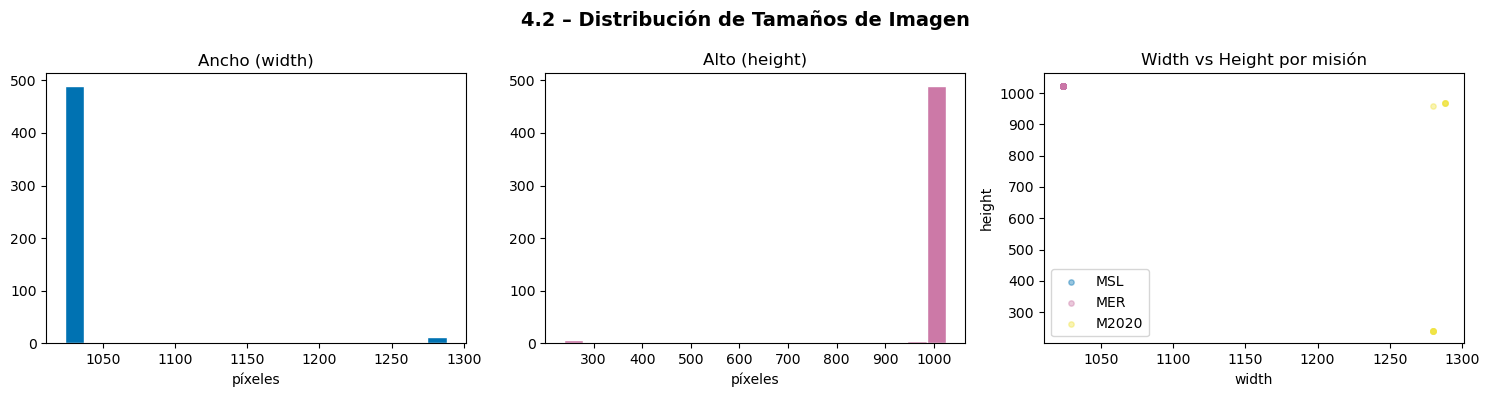

Tamaños más frecuentes:
(1024, 1024)    489
(1280, 240)       6
(1288, 968)       4
(1280, 960)       1

Canales detectados: {1} → mayoría grayscale


In [9]:
def get_all_sizes(df, sample_n=500, seed=EDA_SEED):
    """Mide ancho y alto de una muestra de imágenes."""    
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(df), size=min(sample_n, len(df)), replace=False)
    sizes, img_missions = [], []
    for i in tqdm(idx, desc="Midiendo imágenes"):
        row = df.iloc[i]
        img = Image.open(row["image_path"])
        sizes.append(img.size)   # (width, height)
        img_missions.append(row["mission"])
    return sizes, img_missions

print("Analizando tamaños de imagen...")
sizes, size_missions = get_all_sizes(df_clean, sample_n=500)
widths  = [s[0] for s in sizes]
heights = [s[1] for s in sizes]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("4.2 – Distribución de Tamaños de Imagen", fontsize=14, fontweight="bold")

axes[0].hist(widths,  bins=20, color="#0072B2", edgecolor="white")
axes[0].set_title("Ancho (width)");  axes[0].set_xlabel("píxeles")

axes[1].hist(heights, bins=20, color="#CC79A7", edgecolor="white")
axes[1].set_title("Alto (height)"); axes[1].set_xlabel("píxeles")

for m, color in MISSION_COLORS.items():
    wx = [widths[i]  for i, ms in enumerate(size_missions) if ms == m]
    hy = [heights[i] for i, ms in enumerate(size_missions) if ms == m]
    axes[2].scatter(wx, hy, label=m, alpha=0.4, s=15, color=color)
axes[2].set_xlabel("width"); axes[2].set_ylabel("height")
axes[2].set_title("Width vs Height por misión"); axes[2].legend()

plt.tight_layout()
plt.savefig(PROCESSED_DIR / "eda_04_image_sizes.png", dpi=150, bbox_inches="tight")
plt.show()

unique_sizes = pd.Series(sizes).value_counts()
print("Tamaños más frecuentes:")
print(unique_sizes.head(8).to_string())

# Verificar canales
sample_channels = []
for i in range(min(50, len(df_clean))):
    img = Image.open(df_clean.iloc[i]["image_path"])
    sample_channels.append(len(img.getbands()))
print(f"\nCanales detectados: {set(sample_channels)} → {'mayoría grayscale' if max(set(sample_channels)) == 1 else 'incluye RGB'}")


** Implicaciones – Dimensionalidad y formato**

| | |
|---|---|
| **[D] Decisión** | Resize a **256×256** (o 512×512 si hay GPU suficiente). Aspect ratio varía → resize sin mantener proporción es aceptable porque las máscaras se resizean igual. Normalización: mean=0.456, std=0.224 (grayscale replicado ×3). |
| **[A] Arquitectura** | Todos los modelos recibirán input fijo **[B, 3, 256, 256]** (3 canales por compatibilidad con encoders ImageNet). |
| **[R] Riesgo** | Imágenes muy rectangulares (ej. 1280×240) pierden información geométrica al hacer resize cuadrado. Documentar como limitación estructural. |


---

### 4.3 Distribución de intensidades de píxeles

Se analiza el histograma de intensidades globalmente y por misión para detectar  
saturación, bajo contraste o diferencias sistemáticas entre fuentes de datos.

Analizando distribución de intensidades...


Intensidades: 100%|██████████| 300/300 [00:03<00:00, 88.65it/s]


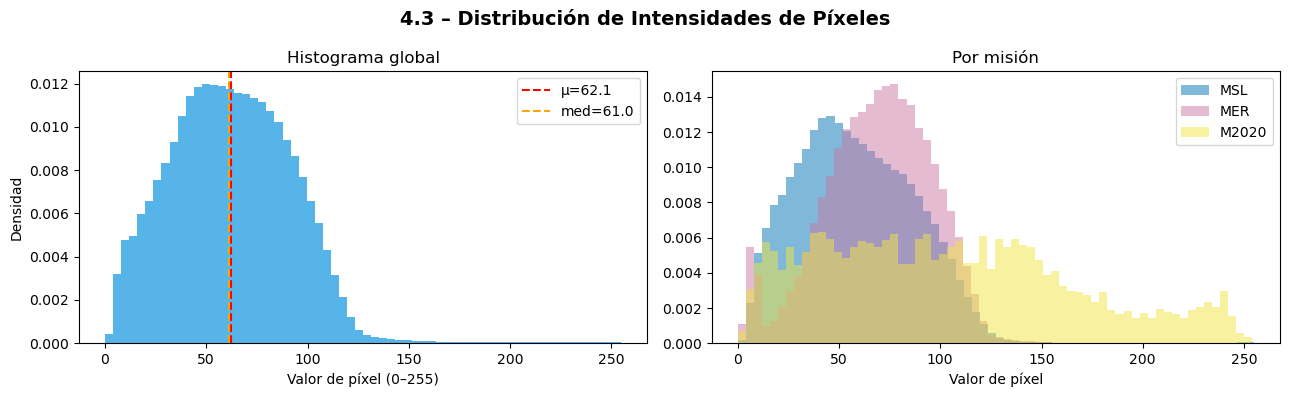

Media global: 62.14  |  Std: 30.28
Píxeles muy oscuros (<10):  2.43%
Píxeles saturados (>245):   0.05%


In [10]:
def pixel_intensity_stats(df, sample_n=300, seed=EDA_SEED):
    """Muestrea píxeles de intensidad de imágenes convertidas a escala de grises."""    
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(df), size=min(sample_n, len(df)), replace=False)
    all_pixels = []
    per_mission = defaultdict(list)
    for i in tqdm(idx, desc="Intensidades"):
        row = df.iloc[i]
        img = np.array(Image.open(row["image_path"]).convert("L")).flatten()
        sample_px = img[rng.choice(len(img), size=min(2000, len(img)), replace=False)]
        all_pixels.extend(sample_px.tolist())
        per_mission[row["mission"]].extend(sample_px.tolist())
    return all_pixels, per_mission

print("Analizando distribución de intensidades...")
all_px, px_mission = pixel_intensity_stats(df_clean, sample_n=300)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("4.3 – Distribución de Intensidades de Píxeles", fontsize=14, fontweight="bold")

axes[0].hist(all_px, bins=64, color="#56B4E9", edgecolor="none", density=True)
axes[0].set_title("Histograma global"); axes[0].set_xlabel("Valor de píxel (0–255)")
axes[0].set_ylabel("Densidad")
axes[0].axvline(np.mean(all_px),   color="red",    linestyle="--", label=f"μ={np.mean(all_px):.1f}")
axes[0].axvline(np.median(all_px), color="orange", linestyle="--", label=f"med={np.median(all_px):.1f}")
axes[0].legend()

for m, color in MISSION_COLORS.items():
    if m in px_mission:
        axes[1].hist(px_mission[m], bins=64, color=color, alpha=0.5,
                     density=True, label=m, edgecolor="none")
axes[1].set_title("Por misión"); axes[1].set_xlabel("Valor de píxel"); axes[1].legend()

plt.tight_layout()
plt.savefig(PROCESSED_DIR / "eda_05_pixel_intensity.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Media global: {np.mean(all_px):.2f}  |  Std: {np.std(all_px):.2f}")
sat_low  = np.mean(np.array(all_px) < 10)
sat_high = np.mean(np.array(all_px) > 245)
print(f"Píxeles muy oscuros (<10):  {sat_low:.2%}")
print(f"Píxeles saturados (>245):   {sat_high:.2%}")


** Implicaciones – Distribución de intensidades**

| | |
|---|---|
| **[D] Decisión** | Normalizar con media y std calculadas **solo sobre TRAIN** (no sobre todo el dataset). Aproximación válida: mean≈0.45, std≈0.22 (escala 0–1), o calcular exactas sobre el split de entrenamiento. |
| **[A] Arquitectura** | Si se usa backbone ImageNet (3 canales), replicar el canal grayscale ×3 y usar stats de ImageNet es válido y habitual. |
| **[R] Riesgo CRÍTICO** | Normalizar con stats del dataset **completo antes del split** → el test set "conoce" la distribución de train. Stats deben calcularse **solo en train**. |


---

### 4.4 Presencia por imagen y co-ocurrencia de clases

En segmentación semántica, la distribución de clases tiene dos dimensiones:  
el **porcentaje de píxeles** (sección 3.1) y la **frecuencia de aparición a nivel imagen**.  
Una clase rara en píxeles pero presente en muchas imágenes es tratable con weighting;  
una clase rara en imágenes además requiere estrategias de oversampling.

Analizando presencia de clases por imagen...


Presencia por imagen: 100%|██████████| 1000/1000 [00:13<00:00, 74.12it/s]


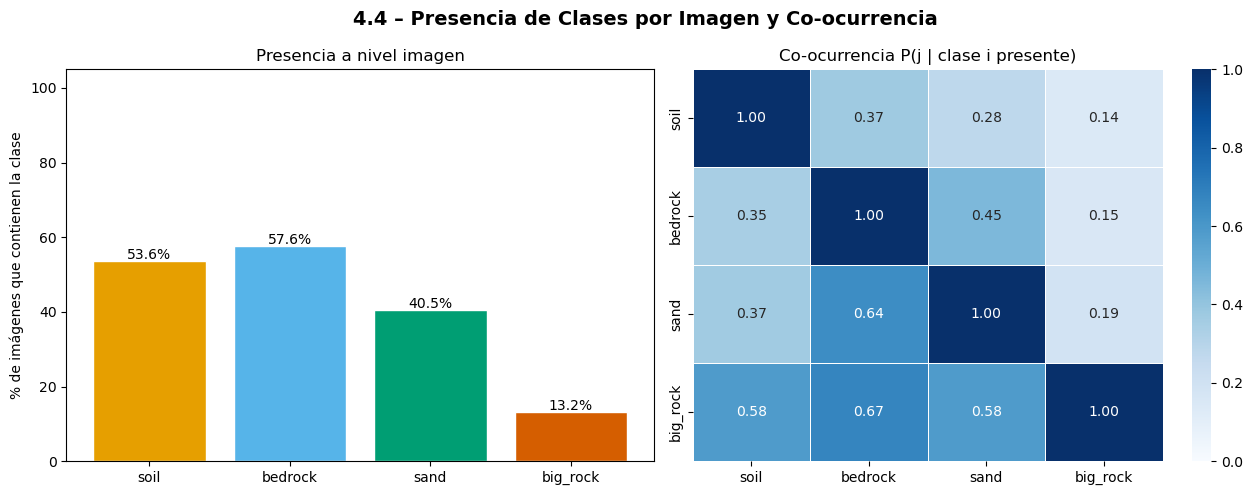


Presencia en 1000 imágenes muestreadas:
  soil      :  536 imágenes  (53.6%)
  bedrock   :  576 imágenes  (57.6%)
  sand      :  405 imágenes  (40.5%)
  big_rock  :  132 imágenes  (13.2%)


In [11]:
def image_level_class_presence(df, sample_n=1000, seed=EDA_SEED):
    """
    Cuenta en cuántas imágenes aparece cada clase (al menos 1 píxel)
    y construye la matriz de co-ocurrencia entre clases.
    """
    presence  = defaultdict(int)
    co_matrix = np.zeros((4, 4), dtype=int)
    sample = df.sample(min(sample_n, len(df)), random_state=seed)

    for _, row in tqdm(sample.iterrows(), total=len(sample), desc="Presencia por imagen"):
        mask = np.array(Image.open(row["mask_path"]))
        classes_in_img = set(np.unique(mask)) - {255}
        for c in classes_in_img:
            if c in [0, 1, 2, 3]:
                presence[c] += 1
        cls_list = [c for c in classes_in_img if c in [0, 1, 2, 3]]
        for i in cls_list:
            for j in cls_list:
                co_matrix[int(i), int(j)] += 1

    return dict(presence), co_matrix, len(sample)

print("Analizando presencia de clases por imagen...")
presence, co_matrix, n_sample = image_level_class_presence(df_clean, sample_n=1000)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("4.4 – Presencia de Clases por Imagen y Co-ocurrencia", fontsize=14, fontweight="bold")

# Barras: % de imágenes que contienen cada clase
pct  = [presence.get(c, 0) / n_sample * 100 for c in [0, 1, 2, 3]]
bars = axes[0].bar(
    [CLASS_COLORS[c][1] for c in [0, 1, 2, 3]],
    pct,
    color=[CLASS_COLORS[c][0] for c in [0, 1, 2, 3]],
    edgecolor="white"
)
for bar, p in zip(bars, pct):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f"{p:.1f}%", ha="center", fontsize=10)
axes[0].set_ylabel("% de imágenes que contienen la clase")
axes[0].set_title("Presencia a nivel imagen"); axes[0].set_ylim(0, 105)

# Heatmap co-ocurrencia normalizado
class_names_4 = [CLASS_COLORS[c][1] for c in [0, 1, 2, 3]]
co_norm = co_matrix.astype(float)
for i in range(4):
    if co_matrix[i, i] > 0:
        co_norm[i] = co_matrix[i] / co_matrix[i, i]
sns.heatmap(co_norm, annot=True, fmt=".2f", xticklabels=class_names_4,
            yticklabels=class_names_4, ax=axes[1], cmap="Blues",
            linewidths=0.5, vmin=0, vmax=1)
axes[1].set_title("Co-ocurrencia P(j | clase i presente)")

plt.tight_layout()
plt.savefig(PROCESSED_DIR / "eda_06_class_presence.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nPresencia en {n_sample} imágenes muestreadas:")
for c in [0, 1, 2, 3]:
    print(f"  {CLASS_COLORS[c][1]:10s}: {presence.get(c,0):4d} imágenes  ({presence.get(c,0)/n_sample:.1%})")


** Implicaciones – Presencia por imagen y co-ocurrencia**

| | |
|---|---|
| **[D] Decisión** | Si `big_rock` aparece en <10% de imágenes Y tiene pocos píxeles → candidato a **hard example mining** o **oversampling a nivel de imagen**. La co-ocurrencia orienta el diseño de augmentaciones coherentes. |
| **[A] Arquitectura** | Justifica **Focal Loss** sobre WeightedCE cuando la clase rara aparece en pocas imágenes (el modelo nunca "practica" con ella). |
| **[R] Riesgo** | Oversampling de imágenes con `big_rock` puede introducir sesgo si esas imágenes provienen mayoritariamente de una sola misión. Verificar distribución de misiones en el subconjunto. |


---

### 4.5 Tamaño efectivo de objetos por clase

Se mide el área en píxeles de cada clase dentro de cada imagen y la fracción respecto al total válido.  
Este análisis determina si objetos pequeños sobrevivirán al resize.

Analizando tamaños de objeto por clase...


Tamaños de objeto: 100%|██████████| 400/400 [00:03<00:00, 109.10it/s]


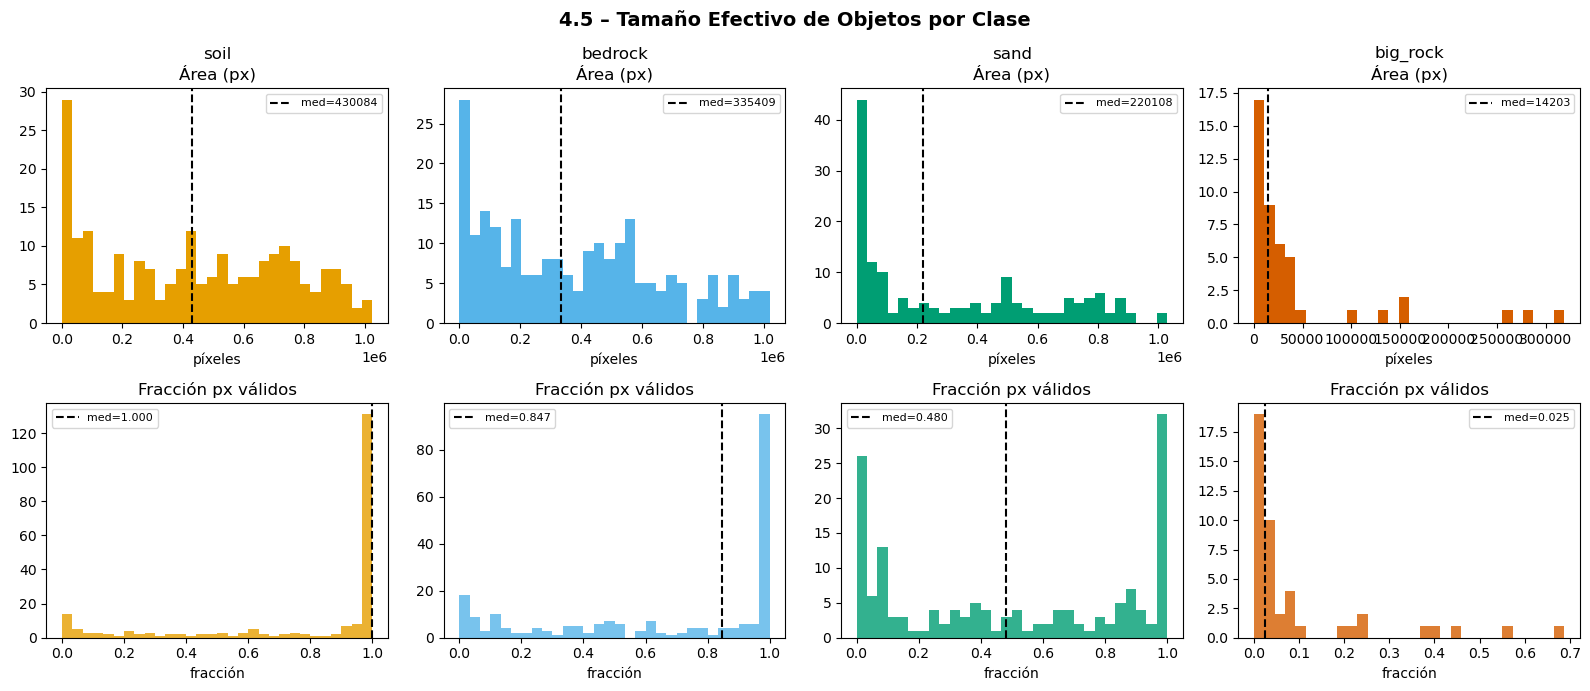


Resumen de tamaños (en imágenes donde aparece la clase):
  soil      : n= 219 | mediana=  430084 px | frac_mediana=1.000 | p5=3647 px | p95=914384 px
  bedrock   : n= 226 | mediana=  335409 px | frac_mediana=0.847 | p5=2020 px | p95=913710 px
  sand      : n= 154 | mediana=  220108 px | frac_mediana=0.480 | p5=619 px | p95=870692 px
  big_rock  : n=  45 | mediana=   14203 px | frac_mediana=0.025 | p5=181 px | p95=242241 px


In [12]:
def object_size_analysis(df, sample_n=400, seed=EDA_SEED):
    """
    Para cada imagen con al menos un píxel de la clase, registra el área
    total (en píxeles) y la fracción respecto a los píxeles válidos.
    """
    results = {c: {"areas": [], "fracs": []} for c in [0, 1, 2, 3]}
    sample = df.sample(min(sample_n, len(df)), random_state=seed)

    for _, row in tqdm(sample.iterrows(), total=len(sample), desc="Tamaños de objeto"):
        mask = np.array(Image.open(row["mask_path"]))
        valid_px = np.sum(mask != 255)
        if valid_px == 0:
            continue
        for c in [0, 1, 2, 3]:
            area = int(np.sum(mask == c))
            if area > 0:
                results[c]["areas"].append(area)
                results[c]["fracs"].append(area / valid_px)
    return results

print("Analizando tamaños de objeto por clase...")
obj_sizes = object_size_analysis(df_clean, sample_n=400)

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
fig.suptitle("4.5 – Tamaño Efectivo de Objetos por Clase", fontsize=14, fontweight="bold")

for col, cls in enumerate([0, 1, 2, 3]):
    areas = obj_sizes[cls]["areas"]
    fracs = obj_sizes[cls]["fracs"]
    color = CLASS_COLORS[cls][0]
    name  = CLASS_COLORS[cls][1]

    axes[0][col].hist(areas, bins=30, color=color, edgecolor="none")
    axes[0][col].set_title(f"{name}\nÁrea (px)")
    axes[0][col].set_xlabel("píxeles")
    if areas:
        axes[0][col].axvline(np.median(areas), color="black", linestyle="--",
                             label=f"med={np.median(areas):.0f}")
        axes[0][col].legend(fontsize=8)

    axes[1][col].hist(fracs, bins=30, color=color, edgecolor="none", alpha=0.8)
    axes[1][col].set_title("Fracción px válidos")
    axes[1][col].set_xlabel("fracción")
    if fracs:
        axes[1][col].axvline(np.median(fracs), color="black", linestyle="--",
                             label=f"med={np.median(fracs):.3f}")
        axes[1][col].legend(fontsize=8)

plt.tight_layout()
plt.savefig(PROCESSED_DIR / "eda_07_object_sizes.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nResumen de tamaños (en imágenes donde aparece la clase):")
for c in [0, 1, 2, 3]:
    areas = obj_sizes[c]["areas"]
    fracs = obj_sizes[c]["fracs"]
    if areas:
        print(f"  {CLASS_COLORS[c][1]:10s}: n={len(areas):4d} | "
              f"mediana={np.median(areas):8.0f} px | "
              f"frac_mediana={np.median(fracs):.3f} | "
              f"p5={np.percentile(areas,5):.0f} px | p95={np.percentile(areas,95):.0f} px")
    else:
        print(f"  {CLASS_COLORS[c][1]:10s}: sin instancias en la muestra")


** Implicaciones – Tamaño efectivo de objetos**

| | |
|---|---|
| **[D] Decisión** | Si `big_rock` tiene área mediana pequeña (<1000 px) → considerar **512×512** en lugar de 256×256 para preservar objetos pequeños. También evaluar *multi-scale inference*. |
| **[A] Arquitectura** | Objetos pequeños favorecen arquitecturas con skip connections finas (**U-Net**) o FPN (*Feature Pyramid Network*) sobre modelos sin path de alta resolución. |
| **[R] Riesgo** | Usar interpolación **NEAREST** para máscaras (no bilinear). El resize bilinear puede hacer desaparecer objetos pequeños por artefactos de interpolación de etiquetas. |


## 5. Análisis Avanzados <a id="avanzados"></a>

Esta sección cuantifica con mayor precisión los riesgos detectados en las secciones anteriores:  
domain shift, píxeles no etiquetados, complejidad espacial de bordes, y separabilidad espectral.

---

### 5.1 Divergencia Jensen-Shannon entre misiones

La divergencia JS cuantifica formalmente el **domain shift** entre pares de misiones.  
Un valor JS > 0.15 indica diferencias distribucionales significativas que requieren atención experimental.

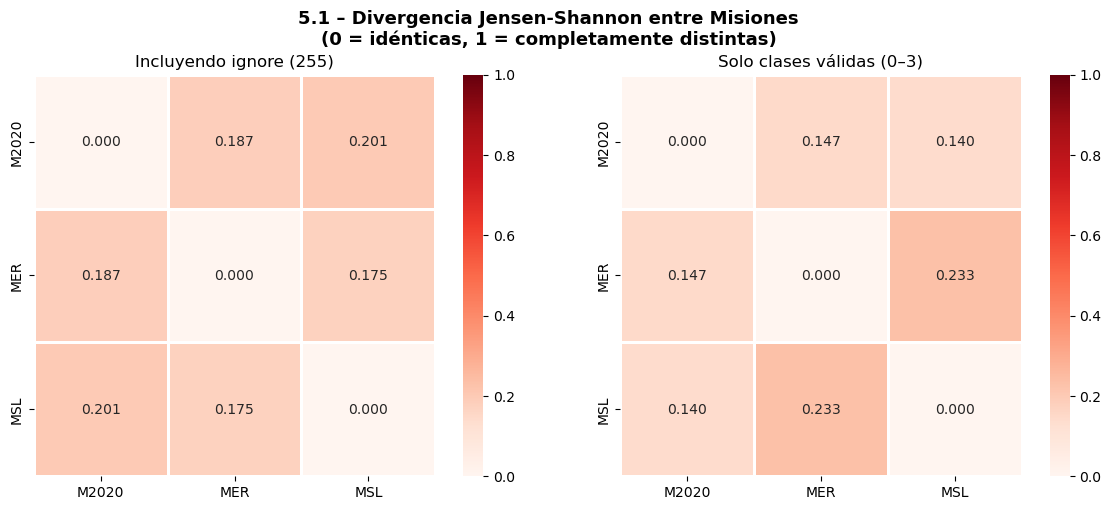

Divergencia Jensen-Shannon (clases válidas 0–3):
  M2020 vs MER: JS = 0.1467  → moderado
  M2020 vs MSL: JS = 0.1405  → moderado
  MER vs MSL: JS = 0.2331  → alto domain shift


In [13]:
def get_dist_vector(dist, classes=[0, 1, 2, 3, 255]):
    """Convierte dict de distribución a vector de probabilidad normalizado."""    
    vec = np.array([dist.get(c, 1e-9) for c in classes], dtype=float)
    return vec / vec.sum()

def get_dist_vector_valid(dist, classes=[0, 1, 2, 3]):
    """Vector de probabilidad solo sobre clases válidas (sin ignore)."""    
    vec = np.array([dist.get(c, 1e-9) for c in classes], dtype=float)
    return vec / vec.sum()

# Usar dist_mission calculado en 3.3 — recalcular si el kernel fue reiniciado
missions = list(dist_mission.keys())
n = len(missions)
js_full  = np.zeros((n, n))
js_valid = np.zeros((n, n))

for i, m1 in enumerate(missions):
    for j, m2 in enumerate(missions):
        v1_f = get_dist_vector(dist_mission[m1])
        v2_f = get_dist_vector(dist_mission[m2])
        js_full[i, j] = jensenshannon(v1_f, v2_f)

        v1_v = get_dist_vector_valid(dist_mission[m1])
        v2_v = get_dist_vector_valid(dist_mission[m2])
        js_valid[i, j] = jensenshannon(v1_v, v2_v)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("5.1 – Divergencia Jensen-Shannon entre Misiones\n(0 = idénticas, 1 = completamente distintas)",
             fontsize=13, fontweight="bold")

for ax, matrix, title in zip(axes, [js_full, js_valid],
                              ["Incluyendo ignore (255)", "Solo clases válidas (0–3)"]):
    sns.heatmap(matrix, annot=True, fmt=".3f", xticklabels=missions,
                yticklabels=missions, ax=ax, cmap="Reds", vmin=0, vmax=1,
                linewidths=1, square=True)
    ax.set_title(title)

plt.tight_layout()
plt.savefig(PROCESSED_DIR / "eda_08_mission_divergence.png", dpi=150, bbox_inches="tight")
plt.show()

print("Divergencia Jensen-Shannon (clases válidas 0–3):")
for i, m1 in enumerate(missions):
    for j, m2 in enumerate(missions):
        if i < j:
            flag = "alto domain shift" if js_valid[i,j] > 0.15 else "moderado"
            print(f"  {m1} vs {m2}: JS = {js_valid[i,j]:.4f}  → {flag}")


** Implicaciones – Divergencia Jensen-Shannon**

| | |
|---|---|
| **[D] Decisión** | JS > 0.15 justifica formalmente el **experimento cross-mission** como benchmark de generalización OOD. Misiones con JS alto no deben mezclarse en val/test sin análisis explícito. |
| **[A] Arquitectura** | Domain shift alto sugiere explorar técnicas de *domain adaptation* (batch norm por misión, adversarial training) como extensión. Documentar como trabajo futuro. |
| **[R] Riesgo** | Un split aleatorio puede colocar muestras de MSL y M2020 en train y test sin control → el modelo puede aprender features específicos de misión y no de terreno. |


---

### 5.2 Análisis de píxeles ignore por imagen

La región ignore (255) varía significativamente entre imágenes y misiones.  
Imágenes con demasiado ignore aportan poco al entrenamiento y pueden sesgar la loss.

Analizando proporción de ignore por imagen...


Ignore ratio: 100%|██████████| 600/600 [00:03<00:00, 194.98it/s]


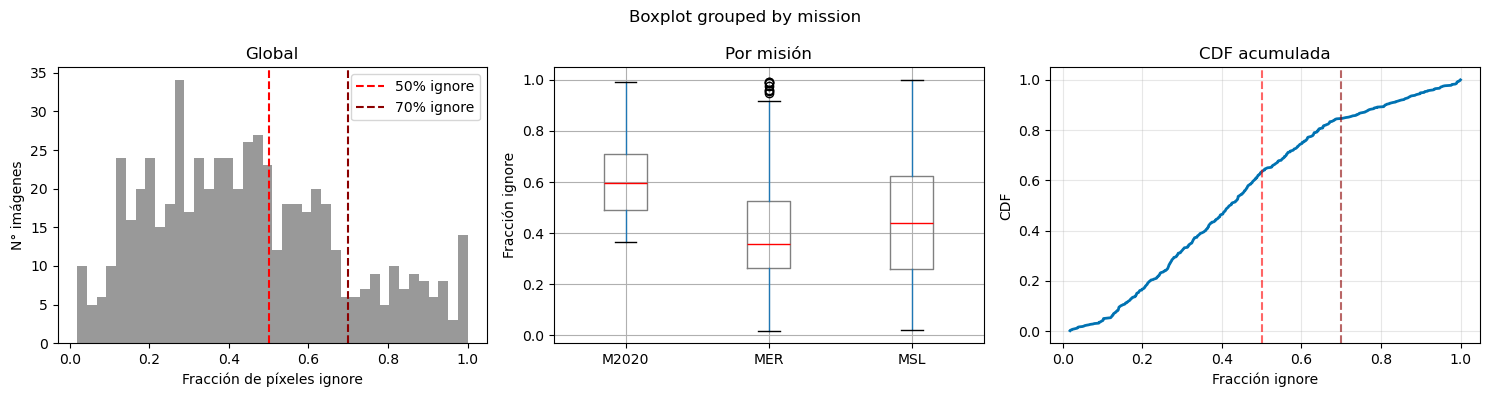


Fracción de imágenes con ignore superior a umbrales:
  > 50%: 36.7% de imágenes  (219 de 600)
  > 70%: 15.5% de imágenes  (93 de 600)
  > 90%: 5.2% de imágenes  (31 de 600)

Estadísticas por misión (fracción de ignore):
         mediana  media
mission                
M2020      0.596  0.632
MER        0.357  0.404
MSL        0.441  0.460


In [14]:
def ignore_ratio_analysis(df, sample_n=600, seed=EDA_SEED):
    """Calcula la fracción de píxeles ignore (255) en cada imagen."""    
    ratios, missions_list = [], []
    sample = df.sample(min(sample_n, len(df)), random_state=seed)
    for _, row in tqdm(sample.iterrows(), total=len(sample), desc="Ignore ratio"):
        mask = np.array(Image.open(row["mask_path"]))
        ratios.append(float(np.mean(mask == 255)))
        missions_list.append(row["mission"])
    return ratios, missions_list

print("Analizando proporción de ignore por imagen...")
ign_ratios, ign_missions = ignore_ratio_analysis(df_clean, sample_n=600)
ign_arr = np.array(ign_ratios)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("5.2 – Distribución de Píxeles Ignore (255) por Imagen", fontsize=14, fontweight="bold")

axes[0].hist(ign_arr, bins=40, color="#999999", edgecolor="none")
axes[0].axvline(0.5, color="red",     linestyle="--", label="50% ignore")
axes[0].axvline(0.7, color="darkred", linestyle="--", label="70% ignore")
axes[0].set_xlabel("Fracción de píxeles ignore"); axes[0].set_ylabel("N° imágenes")
axes[0].set_title("Global"); axes[0].legend()

ign_df = pd.DataFrame({"ratio": ign_ratios, "mission": ign_missions})
ign_df.boxplot(column="ratio", by="mission", ax=axes[1],
               boxprops=dict(color="gray"), medianprops=dict(color="red"))
axes[1].set_title("Por misión"); axes[1].set_xlabel(""); axes[1].set_ylabel("Fracción ignore")
plt.sca(axes[1]); plt.title("Por misión")

sorted_ratios = np.sort(ign_arr)
cdf = np.arange(1, len(sorted_ratios)+1) / len(sorted_ratios)
axes[2].plot(sorted_ratios, cdf, color="#0072B2", linewidth=2)
axes[2].axvline(0.5, color="red",     linestyle="--", alpha=0.6)
axes[2].axvline(0.7, color="darkred", linestyle="--", alpha=0.6)
axes[2].set_xlabel("Fracción ignore"); axes[2].set_ylabel("CDF")
axes[2].set_title("CDF acumulada"); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(PROCESSED_DIR / "eda_09_ignore_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

thresholds = [0.5, 0.7, 0.9]
print("\nFracción de imágenes con ignore superior a umbrales:")
for t in thresholds:
    pct = np.mean(ign_arr > t)
    print(f"  > {t:.0%}: {pct:.1%} de imágenes  ({int(pct*len(ign_arr))} de {len(ign_arr)})")

print("\nEstadísticas por misión (fracción de ignore):")
print(ign_df.groupby("mission")["ratio"].agg(
    mediana="median", media="mean"
).round(3))


** Implicaciones – Ignore por imagen**

| | |
|---|---|
| **[D] Decisión** | Filtrar imágenes con **>90% ignore** antes del entrenamiento (aportan casi cero información útil). Para imágenes con 50–90% ignore: mantener con `ignore_index=255` activo en la loss. |
| **[A] Arquitectura** | Reducir imágenes "basura" mejora la eficiencia de entrenamiento sin pérdida informativa significativa. |
| **[R] Riesgo** | M2020 tiene ~64% ignore en promedio. Un filtro agresivo (>70%) eliminaría casi todo M2020 → el experimento cross-mission se volvería inviable. **Usar umbral 90%.** |


---

### 5.3 Análisis de bordes vs. interior

Los píxeles de frontera entre clases son los más difíciles de predecir correctamente.  
Esta sección cuantifica qué fracción de los píxeles válidos constituyen "zona de borde",  
con análisis de sensibilidad al grosor del kernel de detección.

Analizando bordes vs interior...


Bordes (t=1): 100%|██████████| 300/300 [00:05<00:00, 50.32it/s]


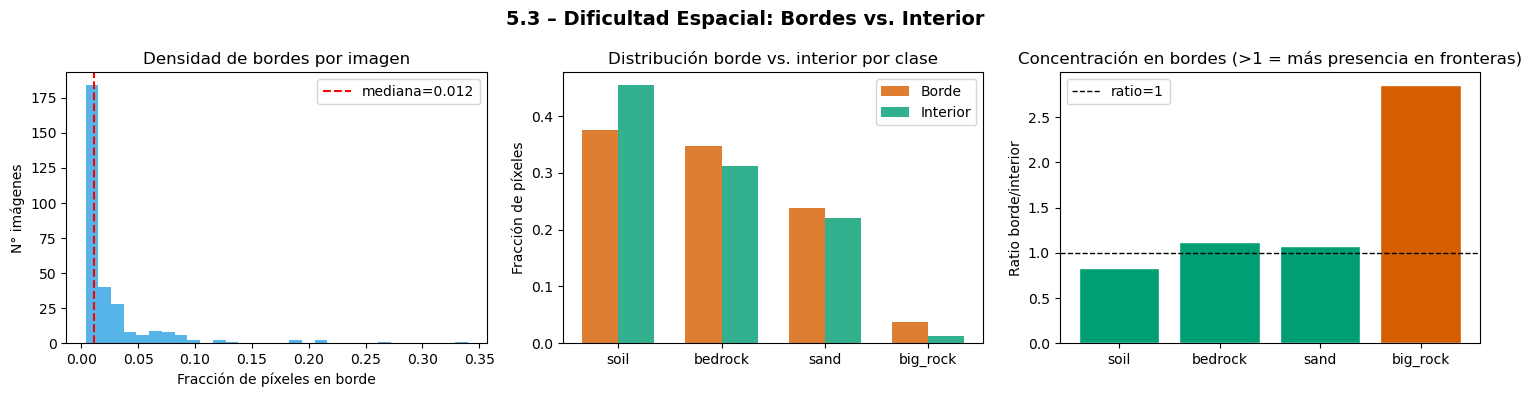


Fracción mediana de píxeles de borde por imagen: 0.012

Ratio borde/interior por clase:
  soil      : 0.828  distribuido
  bedrock   : 1.118  distribuido
  sand      : 1.078  distribuido
  big_rock  : 2.853  concentrado en bordes


In [15]:
def detect_border_pixels(mask, thickness=1):
    """
    Detecta píxeles de borde usando np.pad (edge mode) para evitar
    el artefacto de wrap-around de np.roll.
    thickness > 1 dilata la zona de frontera (simula receptive field CNN).
    """
    padded = np.pad(mask, 1, mode='edge')
    center = padded[1:-1, 1:-1]
    neighbors = [
        padded[:-2, 1:-1], padded[2:,  1:-1],
        padded[1:-1, :-2], padded[1:-1, 2:],
    ]
    is_border = np.zeros_like(center, dtype=bool)
    for nb in neighbors:
        is_border |= (center != nb)
    if thickness > 1:
        is_border = binary_dilation(is_border, iterations=thickness - 1)
    return is_border

def border_vs_interior_analysis(df, n_per_mission=100, seed=EDA_SEED):
    """Calcula estadísticas de borde vs interior para cada clase."""    
    border_counts   = defaultdict(int)
    interior_counts = defaultdict(int)
    border_fracs    = []
    sample = stratified_sample(df, n_per_mission=n_per_mission, seed=seed)

    for _, row in tqdm(sample.iterrows(), total=len(sample), desc="Bordes (t=1)"):
        mask  = np.array(Image.open(row["mask_path"]))
        valid = (mask != 255)
        is_border = detect_border_pixels(mask) & valid
        n_valid   = valid.sum()
        if n_valid > 0:
            border_fracs.append(is_border.sum() / n_valid)
        interior = valid & ~is_border
        for c in [0, 1, 2, 3]:
            border_counts[c]   += int(np.sum(is_border & (mask == c)))
            interior_counts[c] += int(np.sum(interior  & (mask == c)))

    return border_counts, interior_counts, border_fracs

print("Analizando bordes vs interior...")
b_counts, i_counts, b_fracs = border_vs_interior_analysis(df_clean, n_per_mission=100)

b_total = sum(b_counts.values())
i_total = sum(i_counts.values())
b_frac  = {c: b_counts[c] / max(b_total, 1) for c in [0, 1, 2, 3]}
i_frac  = {c: i_counts[c] / max(i_total, 1) for c in [0, 1, 2, 3]}
border_ratio = {c: b_frac[c] / max(i_frac[c], 1e-9) for c in [0, 1, 2, 3]}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("5.3 – Dificultad Espacial: Bordes vs. Interior", fontsize=14, fontweight="bold")

axes[0].hist(b_fracs, bins=30, color="#56B4E9", edgecolor="none")
axes[0].axvline(np.median(b_fracs), color="red", linestyle="--",
                label=f"mediana={np.median(b_fracs):.3f}")
axes[0].set_xlabel("Fracción de píxeles en borde"); axes[0].set_ylabel("N° imágenes")
axes[0].set_title("Densidad de bordes por imagen"); axes[0].legend()

class_names_4 = [CLASS_COLORS[c][1] for c in [0, 1, 2, 3]]
x = np.arange(4); w = 0.35
axes[1].bar(x-w/2, [b_frac[c] for c in range(4)], w, label="Borde",    color="#D55E00", alpha=0.8)
axes[1].bar(x+w/2, [i_frac[c] for c in range(4)], w, label="Interior", color="#009E73", alpha=0.8)
axes[1].set_xticks(x); axes[1].set_xticklabels(class_names_4)
axes[1].set_ylabel("Fracción de píxeles"); axes[1].legend()
axes[1].set_title("Distribución borde vs. interior por clase")

colors_r = ["#D55E00" if v > 1.2 else "#009E73" for v in border_ratio.values()]
axes[2].bar(class_names_4, [border_ratio[c] for c in range(4)],
            color=colors_r, edgecolor="white")
axes[2].axhline(1.0, color="black", linestyle="--", linewidth=1, label="ratio=1")
axes[2].set_ylabel("Ratio borde/interior"); axes[2].legend()
axes[2].set_title("Concentración en bordes (>1 = más presencia en fronteras)")

plt.tight_layout()
plt.savefig(PROCESSED_DIR / "eda_10_border_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nFracción mediana de píxeles de borde por imagen: {np.median(b_fracs):.3f}")
print("\nRatio borde/interior por clase:")
for c in range(4):
    flag = "concentrado en bordes" if border_ratio[c] > 1.3 else "distribuido"
    print(f"  {CLASS_COLORS[c][1]:10s}: {border_ratio[c]:.3f}  {flag}")


Comparando thickness 1, 2, 3 px...


thickness=3: 100%|██████████| 240/240 [00:03<00:00, 60.32it/s]


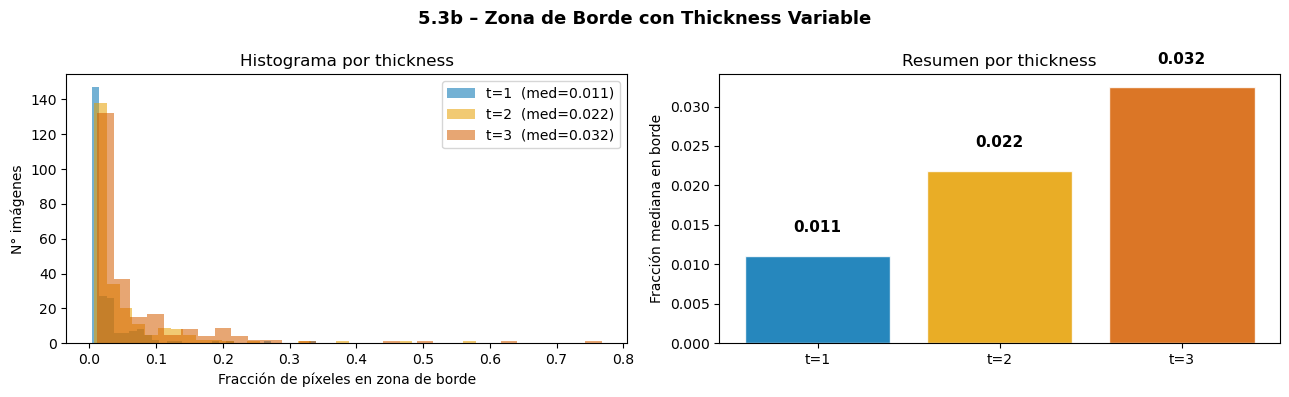

Fracción mediana de bordes por thickness:
  thickness=1px: 0.0111  (1.1% de píxeles válidos)
  thickness=2px: 0.0219  (2.2% de píxeles válidos)
  thickness=3px: 0.0324  (3.2% de píxeles válidos)


In [16]:
# Análisis de sensibilidad al grosor del borde (thickness 1, 2, 3)
def compare_border_thickness(df, n_per_mission=80, seed=EDA_SEED):
    """Evalúa cómo cambia la fracción de píxeles de borde según el grosor del kernel."""    
    results = {}
    for t in [1, 2, 3]:
        fracs = []
        sample = stratified_sample(df, n_per_mission=n_per_mission, seed=seed)
        for _, row in tqdm(sample.iterrows(), total=len(sample), desc=f"thickness={t}"):
            mask  = np.array(Image.open(row["mask_path"]))
            valid = (mask != 255)
            if valid.sum() == 0:
                continue
            border = detect_border_pixels(mask, thickness=t) & valid
            fracs.append(border.sum() / valid.sum())
        results[t] = fracs
    return results

print("Comparando thickness 1, 2, 3 px...")
thickness_results = compare_border_thickness(df_clean, n_per_mission=80)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("5.3b – Zona de Borde con Thickness Variable", fontsize=13, fontweight="bold")

colors_t = {1: "#0072B2", 2: "#E69F00", 3: "#D55E00"}
for t, fracs in thickness_results.items():
    axes[0].hist(fracs, bins=30, alpha=0.55, color=colors_t[t],
                 label=f"t={t}  (med={np.median(fracs):.3f})", edgecolor="none")
axes[0].set_xlabel("Fracción de píxeles en zona de borde")
axes[0].set_ylabel("N° imágenes"); axes[0].legend()
axes[0].set_title("Histograma por thickness")

medians = [np.median(thickness_results[t]) for t in [1, 2, 3]]
axes[1].bar([f"t={t}" for t in [1,2,3]], medians,
            color=[colors_t[t] for t in [1,2,3]], alpha=0.85, edgecolor="white")
for i, v in enumerate(medians):
    axes[1].text(i, v+0.003, f"{v:.3f}", ha="center", fontsize=11, fontweight="bold")
axes[1].set_ylabel("Fracción mediana en borde")
axes[1].set_title("Resumen por thickness")

plt.tight_layout()
plt.savefig(PROCESSED_DIR / "eda_10b_boundary_thickness.png", dpi=150, bbox_inches="tight")
plt.show()

print("Fracción mediana de bordes por thickness:")
for t in [1, 2, 3]:
    med = np.median(thickness_results[t])
    print(f"  thickness={t}px: {med:.4f}  ({med*100:.1f}% de píxeles válidos)")


** Implicaciones – Análisis de bordes**

| | |
|---|---|
| **[D] Decisión** | Si fracción de borde con t=2 > 30% → **Dice Loss** es imprescindible como complemento de CE (Dice es más sensible a bordes y regiones pequeñas). Usar `thickness=2` para análisis (más alineado con el receptive field de capas conv 3×3). |
| **[A] Arquitectura** | Alta fracción de borde favorece **U-Net** (skip connections preservan detalle espacial) sobre DeepLab sin decoder detallado. SegFormer-B0 puede fallar en bordes finos. |
| **[R] Riesgo** | `np.roll` genera bordes artificiales en los extremos de la imagen (wrap-around). Se usa `np.pad(mode='edge')` como corrección. Bordes ruidosos en el etiquetado del dataset son ruido estructural, no del modelo. |


---

### 5.4 Balance real de batches – WeightedRandomSampler vs. muestreo aleatorio

Simula el balance de misiones en cada batch bajo los dos esquemas de muestreo.  
Confirma que el `WeightedRandomSampler` es necesario para exponer M2020 al modelo durante el entrenamiento.

Simulando 200 batches (batch_size=16)...


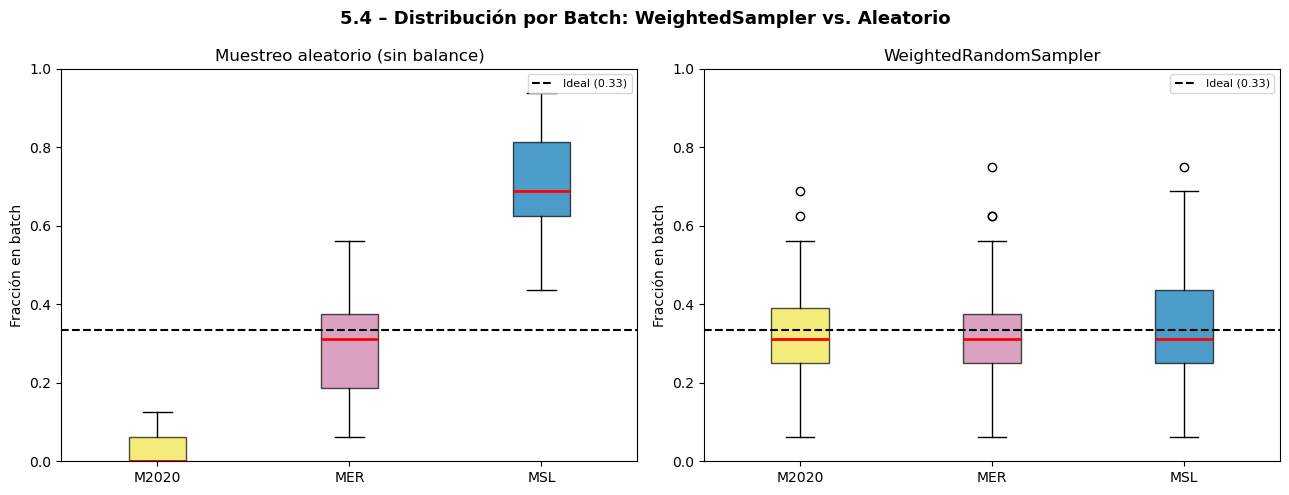


Media ± std de fracción por misión en batch:

  [Aleatorio]
    M2020: 0.020 ± 0.033
    MER: 0.285 ± 0.116
    MSL: 0.695 ± 0.118

  [Weighted]
    M2020: 0.332 ± 0.114
    MER: 0.329 ± 0.118
    MSL: 0.340 ± 0.121


In [17]:
def simulate_weighted_sampling(df, n_batches=200, batch_size=16, seed=EDA_SEED):
    """Simula distribución de misiones en batches con WeightedRandomSampler."""    
    mission_counts = df["mission"].value_counts().to_dict()
    weights = df["mission"].map(lambda m: 1.0 / mission_counts[m]).values
    weights /= weights.sum()
    rng = np.random.default_rng(seed)
    return [
        df.iloc[rng.choice(len(df), size=batch_size, replace=True, p=weights)
               ]["mission"].value_counts(normalize=True).to_dict()
        for _ in range(n_batches)
    ]

def simulate_uniform_sampling(df, n_batches=200, batch_size=16, seed=EDA_SEED):
    """Simula distribución de misiones en batches con muestreo aleatorio uniforme."""    
    rng = np.random.default_rng(seed)
    return [
        df.iloc[rng.choice(len(df), size=batch_size, replace=False)
               ]["mission"].value_counts(normalize=True).to_dict()
        for _ in range(n_batches)
    ]

print("Simulando 200 batches (batch_size=16)...")
weighted_batches = simulate_weighted_sampling(df_clean)
uniform_batches  = simulate_uniform_sampling(df_clean)
missions_all     = sorted(df_clean["mission"].unique())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("5.4 – Distribución por Batch: WeightedSampler vs. Aleatorio",
             fontsize=13, fontweight="bold")

for ax, batches, title in zip(
    axes,
    [uniform_batches, weighted_batches],
    ["Muestreo aleatorio (sin balance)", "WeightedRandomSampler"]
):
    bp = ax.boxplot(
        [[b.get(m, 0) for b in batches] for m in missions_all],
        labels=missions_all, patch_artist=True,
        medianprops=dict(color="red", linewidth=2)
    )
    for patch, m in zip(bp["boxes"], missions_all):
        patch.set_facecolor(MISSION_COLORS[m]); patch.set_alpha(0.7)
    ax.axhline(1/len(missions_all), color="black", linestyle="--",
               linewidth=1.5, label=f"Ideal ({1/len(missions_all):.2f})")
    ax.set_ylabel("Fracción en batch"); ax.set_title(title)
    ax.legend(fontsize=8); ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig(PROCESSED_DIR / "eda_11_batch_balance.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nMedia ± std de fracción por misión en batch:")
for title, batches in [("Aleatorio", uniform_batches), ("Weighted", weighted_batches)]:
    print(f"\n  [{title}]")
    for m in missions_all:
        vals = [b.get(m, 0) for b in batches]
        print(f"    {m}: {np.mean(vals):.3f} ± {np.std(vals):.3f}")


** Implicaciones – Balance de batches**

| | |
|---|---|
| **[D] Decisión** | Usar **WeightedRandomSampler** (por misión) + **WeightedCE** (por clase) como estrategia dual de balanceo. Son ortogonales: el sampler balancea misiones, la loss balancea clases. |
| **[A] Arquitectura** | M2020 pasa de aparecer <1 vez cada 6 batches a ~5 veces por batch con Weighted Sampler → el modelo aprende representaciones de esa misión. |
| **[R] Riesgo** | Oversampling con replacement puede generar repetición excesiva de imágenes de M2020 (solo 471 muestras). Monitorear la loss por misión durante el entrenamiento. |


---

### 5.5 Correlación intensidad ↔ clase (KS-test)

Se examina si las clases tienen distribuciones de intensidad estadísticamente distintas.  
El test de Kolmogorov-Smirnov cuantifica la separabilidad entre pares de clases basada solo en el valor de píxel.

Analizando correlación intensidad ↔ clase...


Intensidad por clase: 100%|██████████| 300/300 [00:06<00:00, 45.36it/s]


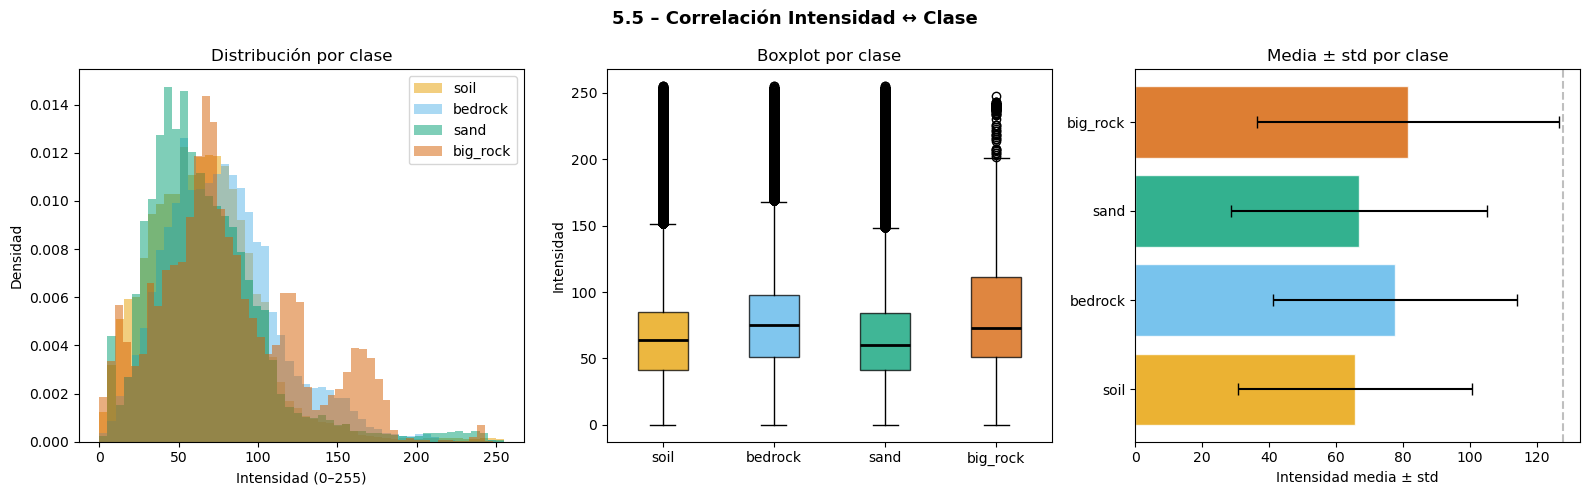


── Kolmogorov-Smirnov: separabilidad por intensidad ──
Par                     KS stat       p-valor  Interpretación
─────────────────────────────────────────────────────────────────
soil       vs bedrock       0.1291      0.00e+00  distintas (bajo)
soil       vs sand          0.0459     4.30e-156  distintas (bajo)
soil       vs big_rock      0.1764      0.00e+00  distintas (moderado)
bedrock    vs sand          0.1618      0.00e+00  distintas (moderado)
bedrock    vs big_rock      0.0992     8.64e-125  distintas (bajo)
sand       vs big_rock      0.1712      0.00e+00  distintas (moderado)


In [18]:
def intensity_per_class(df, n_per_mission=100, px_per_img=2000, seed=EDA_SEED):
    """
    Extrae muestras de píxeles con su intensidad e identidad de clase,
    usando sampling estratificado por misión.
    """
    records = []
    rng = np.random.default_rng(seed)
    sample = stratified_sample(df, n_per_mission=n_per_mission, seed=seed)

    for _, row in tqdm(sample.iterrows(), total=len(sample), desc="Intensidad por clase"):
        img  = np.array(Image.open(row["image_path"]).convert("L"))
        mask = np.array(Image.open(row["mask_path"]))
        valid_idx = np.where(mask != 255)
        if len(valid_idx[0]) == 0:
            continue
        n = min(px_per_img, len(valid_idx[0]))
        chosen   = rng.choice(len(valid_idx[0]), size=n, replace=False)
        rows_px  = valid_idx[0][chosen]
        cols_px  = valid_idx[1][chosen]
        for intensity, cls in zip(img[rows_px, cols_px], mask[rows_px, cols_px]):
            if cls in [0, 1, 2, 3]:
                records.append({"intensity": int(intensity),
                                 "class": int(cls),
                                 "class_name": CLASS_COLORS[int(cls)][1]})
    return pd.DataFrame(records)

print("Analizando correlación intensidad ↔ clase...")
df_intensity = intensity_per_class(df_clean, n_per_mission=100)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("5.5 – Correlación Intensidad ↔ Clase", fontsize=13, fontweight="bold")

for cls in [0, 1, 2, 3]:
    sub = df_intensity[df_intensity["class"] == cls]["intensity"]
    if len(sub) > 10:
        axes[0].hist(sub, bins=50, alpha=0.5, density=True,
                     color=CLASS_COLORS[cls][0], label=CLASS_COLORS[cls][1])
axes[0].set_xlabel("Intensidad (0–255)"); axes[0].set_ylabel("Densidad")
axes[0].set_title("Distribución por clase"); axes[0].legend()

bp_data = [df_intensity[df_intensity["class"] == c]["intensity"].values for c in [0, 1, 2, 3]]
bp = axes[1].boxplot(bp_data, labels=class_names_4, patch_artist=True,
                     medianprops=dict(color="black", linewidth=2))
for patch, cls in zip(bp["boxes"], [0, 1, 2, 3]):
    patch.set_facecolor(CLASS_COLORS[cls][0]); patch.set_alpha(0.75)
axes[1].set_ylabel("Intensidad"); axes[1].set_title("Boxplot por clase")

stats = df_intensity.groupby("class")["intensity"].agg(["mean", "std"])
stats.index = class_names_4
axes[2].barh(stats.index, stats["mean"], xerr=stats["std"],
             color=[CLASS_COLORS[c][0] for c in [0, 1, 2, 3]],
             alpha=0.8, edgecolor="white", capsize=4)
axes[2].set_xlabel("Intensidad media ± std"); axes[2].set_title("Media ± std por clase")
axes[2].axvline(128, color="gray", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig(PROCESSED_DIR / "eda_12_intensity_class.png", dpi=150, bbox_inches="tight")
plt.show()

# ── KS-test: separabilidad estadística entre pares ──────────────────────────
print("\n── Kolmogorov-Smirnov: separabilidad por intensidad ──")
print(f"{'Par':<22} {'KS stat':>8}  {'p-valor':>12}  Interpretación")
print("─" * 65)
for i in range(4):
    for j in range(i+1, 4):
        s1 = df_intensity[df_intensity["class"] == i]["intensity"].values
        s2 = df_intensity[df_intensity["class"] == j]["intensity"].values
        if len(s1) > 0 and len(s2) > 0:
            ks = ks_2samp(s1, s2)
            sep  = "distintas" if ks.pvalue < 0.05 else "  solapamiento"
            high = " (alto)" if ks.statistic > 0.3 else (" (moderado)" if ks.statistic > 0.15 else " (bajo)")
            print(f"{CLASS_COLORS[i][1]:10} vs {CLASS_COLORS[j][1]:10}  "
                  f"{ks.statistic:>8.4f}  {ks.pvalue:>12.2e}  {sep}{high}")


** Implicaciones – Correlación intensidad ↔ clase**

| | |
|---|---|
| **[D] Decisión** | KS p < 0.05 confirma que las distribuciones son estadísticamente distintas → la intensidad tiene **poder discriminativo**. Sin embargo, KS stat < 0.3 en pares similares indica solapamiento → el modelo necesita **contexto espacial**, no solo información puntual de píxel. |
| **[A] Arquitectura** | Justifica **CNNs** (capturan textura local) y arquitecturas con **ASPP** (contexto global). Un clasificador por píxel puro fallará en las clases con alta superposición de intensidades. |
| **[R] Riesgo** | Alta separabilidad estadística no implica separabilidad visual. Siempre validar con inspección cualitativa (sección 4.1). |


## 6. Baselines triviales (lower bound de mIoU) <a id="baselines"></a>

Se calculan tres baselines teóricos y uno empírico que representan el rendimiento mínimo esperable.  
Cualquier modelo entrenado debe superar claramente el **baseline empírico C**.

- **Baseline A** – Siempre predice la clase dominante (pésimo mIoU por penalización en 3 clases con IoU=0)
- **Baseline B** – Predicción aleatoria proporcional, teórico optimista (asume independencia espacial)
- **Baseline C** – Predicción aleatoria proporcional, empírico real (mide correlación espacial real)

Calculando baselines teóricos...


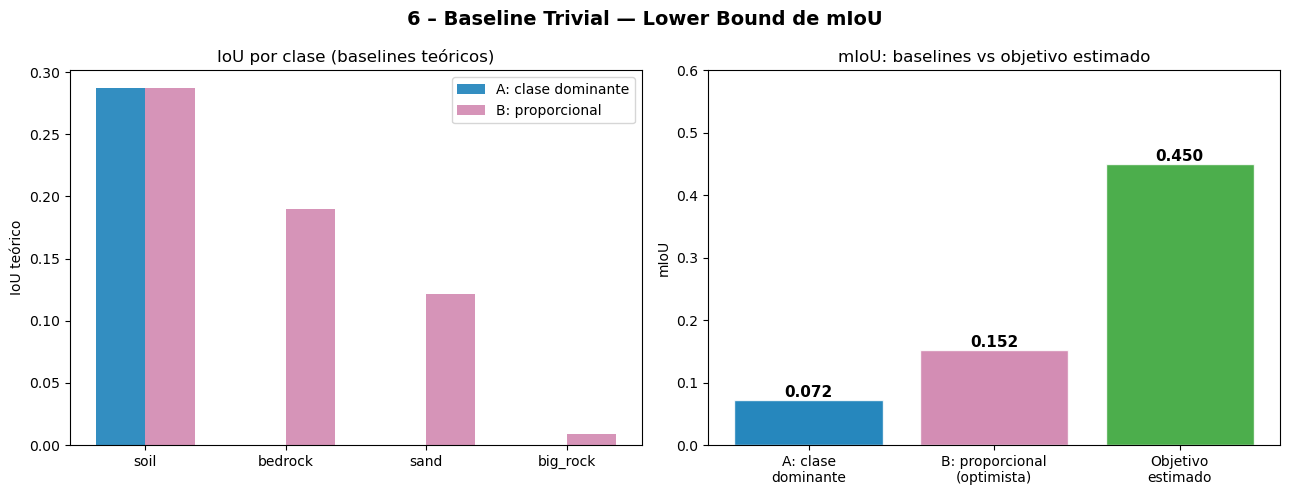

Baseline A (siempre 'soil'): mIoU = 0.0718
Baseline B (proporcional teórico): mIoU = 0.1519


In [19]:
def compute_theoretical_iou(class_freqs, num_classes=4):
    """Calcula IoU teórico para estrategias de baseline trivial."""    
    freqs = np.array([class_freqs.get(c, 0) for c in range(num_classes)], dtype=float)
    freqs /= freqs.sum()

    # Estrategia A: siempre predice la clase dominante
    dom = int(np.argmax(freqs))
    iou_a = np.zeros(num_classes)
    iou_a[dom] = freqs[dom] / (2.0 - freqs[dom])
    miou_a = float(np.mean(iou_a))

    # Estrategia B: predicción proporcional (límite superior optimista)
    iou_b  = freqs**2 / (2*freqs - freqs**2 + 1e-9)
    miou_b = float(np.mean(iou_b))

    return {
        "strategy_A": {"per_class": iou_a, "mIoU": miou_a, "dominant_class": dom},
        "strategy_B": {"per_class": iou_b, "mIoU": miou_b},
        "freqs": freqs,
    }

print("Calculando baselines teóricos...")
valid_counts = {c: counts_global.get(c, 0) for c in [0, 1, 2, 3]}
baseline     = compute_theoretical_iou(valid_counts)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("6 – Baseline Trivial — Lower Bound de mIoU", fontsize=14, fontweight="bold")

class_names_4 = [CLASS_COLORS[c][1] for c in range(4)]
x = np.arange(4); w = 0.35
axes[0].bar(x-w/2, baseline["strategy_A"]["per_class"], w,
            label="A: clase dominante", color="#0072B2", alpha=0.8)
axes[0].bar(x+w/2, baseline["strategy_B"]["per_class"], w,
            label="B: proporcional",    color="#CC79A7", alpha=0.8)
axes[0].set_xticks(x); axes[0].set_xticklabels(class_names_4)
axes[0].set_ylabel("IoU teórico"); axes[0].legend()
axes[0].set_title("IoU por clase (baselines teóricos)")

strategies = ["A: clase\ndominante", "B: proporcional\n(optimista)", "Objetivo\nestimado"]
miou_vals  = [baseline["strategy_A"]["mIoU"], baseline["strategy_B"]["mIoU"], 0.45]
bars = axes[1].bar(strategies, miou_vals,
                   color=["#0072B2","#CC79A7","#2CA02C"], alpha=0.85, edgecolor="white")
for bar, v in zip(bars, miou_vals):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                 f"{v:.3f}", ha="center", fontsize=11, fontweight="bold")
axes[1].set_ylabel("mIoU"); axes[1].set_ylim(0, 0.6)
axes[1].set_title("mIoU: baselines vs objetivo estimado")

plt.tight_layout()
plt.savefig(PROCESSED_DIR / "eda_13_baseline_iou.png", dpi=150, bbox_inches="tight")
plt.show()

dom_name = CLASS_COLORS[baseline["strategy_A"]["dominant_class"]][1]
print(f"Baseline A (siempre '{dom_name}'): mIoU = {baseline['strategy_A']['mIoU']:.4f}")
print(f"Baseline B (proporcional teórico): mIoU = {baseline['strategy_B']['mIoU']:.4f}")


Calculando baseline empírico C (puede tardar ~1 min)...


Baseline empírico C: 100%|██████████| 300/300 [00:06<00:00, 46.64it/s]


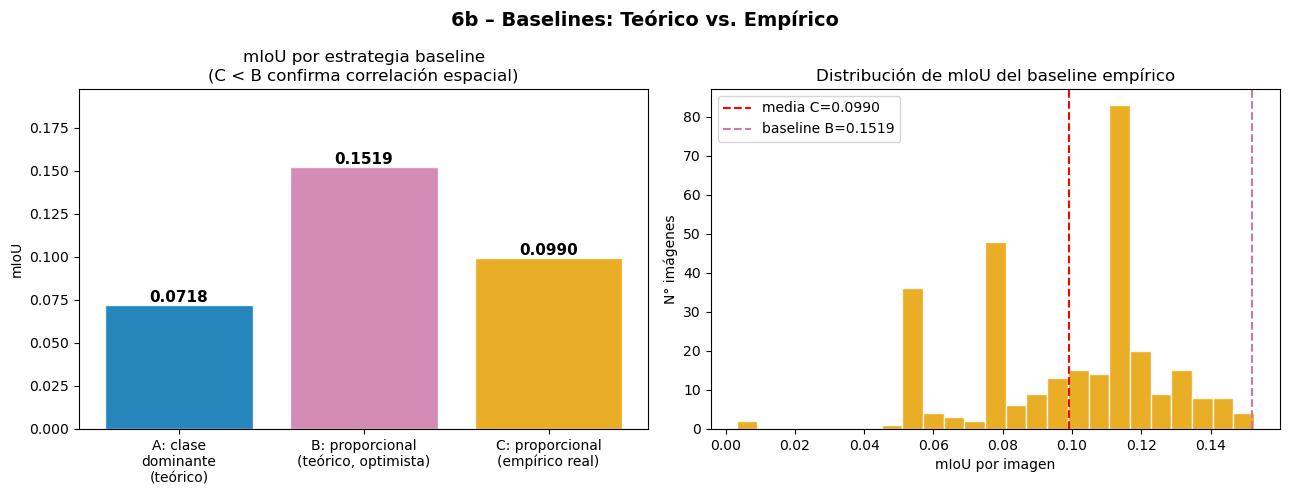

Baseline A (teórico, pesimista):   mIoU = 0.0718
Baseline B (teórico, optimista):   mIoU = 0.1519
Baseline C (empírico, real):       mIoU = 0.0990  ← usar como referencia
Gap B − C = 0.0529  → correlación espacial reduce el baseline real en 0.0529

→ Cualquier modelo con mIoU > 0.099 supera el predictor aleatorio.
→ Objetivo realista: mIoU ∈ [0.35, 0.55]


In [20]:
def compute_empirical_baseline(df, n_masks=300, n_per_mission=100, seed=EDA_SEED):
    """
    Baseline C empírico: predicción aleatoria proporcional evaluada sobre
    máscaras reales. Calcula IoU real píxel a píxel sobre muestras del dataset.
    El resultado es MENOR que baseline B porque la correlación espacial en
    máscaras reales penaliza los predictores aleatorios.
    """
    counts = pixel_class_counts(df, n_per_mission=n_per_mission, seed=seed)
    valid_counts = np.array([counts.get(c, 0) for c in range(4)], dtype=float)
    probs = valid_counts / valid_counts.sum()

    rng    = np.random.default_rng(seed)
    sample = stratified_sample(df, n_per_mission=n_masks//3, seed=seed+1)
    iou_per_run = []

    for _, row in tqdm(sample.iterrows(), total=len(sample), desc="Baseline empírico C"):
        mask  = np.array(Image.open(row["mask_path"]))
        valid = (mask != 255)
        if valid.sum() < 100:
            continue
        n_valid   = valid.sum()
        pred_flat = rng.choice(4, size=n_valid, p=probs)
        true_flat = mask[valid]
        ious = []
        for c in range(4):
            tp    = np.sum((pred_flat == c) & (true_flat == c))
            fp    = np.sum((pred_flat == c) & (true_flat != c))
            fn    = np.sum((pred_flat != c) & (true_flat == c))
            denom = tp + fp + fn
            ious.append(tp / denom if denom > 0 else 0.0)
        iou_per_run.append(np.mean(ious))

    return np.array(iou_per_run), probs

print("Calculando baseline empírico C (puede tardar ~1 min)...")
empirical_ious, class_probs = compute_empirical_baseline(df_clean, n_masks=300)

miou_a = baseline["strategy_A"]["mIoU"]
miou_b = baseline["strategy_B"]["mIoU"]
miou_c = float(np.mean(empirical_ious))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("6b – Baselines: Teórico vs. Empírico", fontsize=14, fontweight="bold")

labels = ["A: clase\ndominante\n(teórico)", "B: proporcional\n(teórico, optimista)",
          "C: proporcional\n(empírico real)"]
mious  = [miou_a, miou_b, miou_c]
colors_bl = ["#0072B2", "#CC79A7", "#E69F00"]
bars = axes[0].bar(labels, mious, color=colors_bl, alpha=0.85, edgecolor="white")
for bar, v in zip(bars, mious):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
                 f"{v:.4f}", ha="center", fontsize=11, fontweight="bold")
axes[0].set_ylabel("mIoU"); axes[0].set_ylim(0, max(mious)*1.3)
axes[0].set_title("mIoU por estrategia baseline\n(C < B confirma correlación espacial)")

axes[1].hist(empirical_ious, bins=25, color="#E69F00", edgecolor="white", alpha=0.85)
axes[1].axvline(miou_c, color="red",     linestyle="--", label=f"media C={miou_c:.4f}")
axes[1].axvline(miou_b, color="#CC79A7", linestyle="--", label=f"baseline B={miou_b:.4f}")
axes[1].set_xlabel("mIoU por imagen"); axes[1].set_ylabel("N° imágenes")
axes[1].set_title("Distribución de mIoU del baseline empírico"); axes[1].legend()

plt.tight_layout()
plt.savefig(PROCESSED_DIR / "eda_13b_empirical_baseline.png", dpi=150, bbox_inches="tight")
plt.show()

gap = miou_b - miou_c
print(f"Baseline A (teórico, pesimista):   mIoU = {miou_a:.4f}")
print(f"Baseline B (teórico, optimista):   mIoU = {miou_b:.4f}")
print(f"Baseline C (empírico, real):       mIoU = {miou_c:.4f}  ← usar como referencia")
print(f"Gap B − C = {gap:.4f}  → correlación espacial reduce el baseline real en {gap:.4f}")
print(f"\n→ Cualquier modelo con mIoU > {miou_c:.3f} supera el predictor aleatorio.")
print(f"→ Objetivo realista: mIoU ∈ [0.35, 0.55]")


** Implicaciones – Baselines triviales**

| | |
|---|---|
| **[D] Decisión** | Usar **baseline C** como referencia principal en la tabla comparativa de benchmarks. Es el único baseline que mide rendimiento real sobre las máscaras del dataset. |
| **[A] Arquitectura** | Gap(B−C) > 0 confirma que la correlación espacial es explotable → arquitecturas con contexto (ASPP, skip connections) deben superar baseline C por margen significativo. |
| **[R] Riesgo** | Baseline B sobreestima el lower bound. Reportar **siempre baseline C** para no inflar artificialmente el mérito del modelo respecto al azar. |


## 7. Tabla resumen EDA → Decisiones de modelado <a id="resumen"></a>

Síntesis de todos los hallazgos y su mapeo directo a componentes del pipeline de modelado.  
Cada fila representa una decisión de diseño **justificada empíricamente** por el análisis anterior.

| Hallazgo EDA | Decisión de diseño | Componente | Riesgo controlado |
|---|---|---|---|
| `big_rock` = ~0.4 % de píxeles válidos | Focal Loss γ=2 / WeightedCE (pesos ∝ 1/freq) | Loss function | Pixel accuracy es engañosa como métrica principal |
| `big_rock` presente en <10 % de imágenes | WeightedSampler + oversampling de imágenes con la clase | Sampler / DataLoader | Oversampling sesgado si big_rock se concentra en una sola misión |
| Fracción de borde (t=2) > 20 % de píxeles válidos | Loss combinada: 0.5·CE + 0.5·Dice | Loss function | Bordes ruidosos en el etiquetado son ruido estructural del dataset |
| Solapamiento de intensidades (KS stat < 0.3 en pares similares) | Arquitectura con ASPP (DeepLabV3+) o skip connections (U-Net) | Arquitectura | Un clasificador puntual sin contexto espacial fallará |
| Domain shift entre misiones (JS > 0.15) | Evaluar globalmente **y** por misión; experimento cross-mission obligatorio | Protocolo experimental | Split aleatorio sin control = violación OOD implícita |
| M2020 representa ~2 % del dataset | `WeightedRandomSampler` por misión en el DataLoader | DataLoader | Oversampling con replacement en un conjunto pequeño (471 muestras) |
| ignore = ~45 % de todos los píxeles | `CrossEntropyLoss(ignore_index=255)` | Loss function | Loss sesgada si `ignore_index` no está activo |
| Resoluciones variables (240–1288 px) | Resize 256×256; interpolación NEAREST para máscaras | Preprocesamiento | `big_rock` puede desaparecer en resize agresivo sin NEAREST |
| Baseline C empírico calculado | Cualquier modelo debe superar este mIoU como umbral mínimo | Benchmark | Baseline B (teórico) sobreestima el lower bound real |
| Sin duplicados exactos detectados (muestra n=1000) | Verificar dataset completo antes del split final | Preprocesamiento | Duplicados entre train y test = data leakage directo |

> **Notas metodológicas:**  
> - Los splits `split_train.csv`, `split_val.csv`, `split_test.csv` están guardados y deben reutilizarse en todos los notebooks de modelos sin regenerar.  
> - Las estadísticas de normalización (media, std) deben calcularse **solo sobre train** y aplicarse a val/test.

## Implicaciones para el modelado — Resumen ejecutivo

###  Preprocesamiento
- Resize a **256×256**: interpolación `BILINEAR` para imágenes, `NEAREST` para máscaras.
- Normalización con media/std calculadas **solo sobre el train set** (no sobre el dataset completo).
- Filtrar imágenes con **>90 % de ignore** antes del split (umbral conservador para no perder M2020).
- Replicar canal grayscale ×3 para compatibilidad con encoders preentrenados en ImageNet.

###  Función de pérdida
| Experimento | Loss | Justificación |
|---|---|---|
| Baseline | `CrossEntropyLoss(ignore_index=255)` | Control |
| Exp 2 | `WeightedCE` (pesos ∝ 1/freq) | Desbalance extremo en big_rock |
| Exp 3 | `Focal Loss` (γ=2) | big_rock raro a nivel imagen |
| Exp 4 | `0.5·CE + 0.5·Dice` | Alta fracción de borde (t=2) |

###  Muestreo y splits
- Split **70/15/15 estratificado por misión** — splits guardados en CSV, invariantes entre experimentos.
- `WeightedRandomSampler` en train para equiparar la frecuencia de misiones por batch.
- Evaluar métricas **globales** y **por misión** en val y test.

###  Arquitectura
- Encoder-decoder con skip connections: **U-Net** (ResNet-34/50) o **DeepLabV3+** (EfficientNet-B2).
- Backbone preentrenado en ImageNet; cabeza de clasificación con **4 salidas** (clases 0–3).
- Input fijo: `[B, 3, 256, 256]`.
- ASPP o atrous convolutions para capturar contexto global (clases con solapamiento de intensidad).

###  Experimentos requeridos
1. **Baseline**: train mezclado, evaluación global.
2. **Cross-mission**: train MSL+MER, test M2020 (justificado por JS > 0.15).
3. **Comparativa de loss**: CE vs WeightedCE vs Focal vs Combo.
4. Mínimo **3 semillas** por experimento → reportar **media ± std**.

###  Métricas
| Métrica | Rol |
|---|---|
| **mIoU** (excluyendo clase 255) | Métrica principal |
| **IoU por clase** (especialmente big_rock) | Diagnóstico de clases raras |
| Dice coefficient | Complementario a mIoU |
| Pixel accuracy | Solo referencia — **no usar como métrica principal** |

### Riesgos controlados
- **Data leakage 1**: stats de normalización calculadas solo en train. 
- **Data leakage 2**: splits guardados en CSV, no se regeneran. 
- **Data leakage 3**: duplicados verificados — ninguno detectado en muestra (verificar dataset completo). 
- **Interpolación**: NEAREST en todo resize de máscaras. 
- **Baseline de referencia**: usar baseline C empírico, no baseline B teórico. 